In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from scipy.stats import kurtosis
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter


In [2]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

In [3]:
df = pd.read_excel(fpath + '\\10.0_database_variables.xlsx', sheet_name = 'database_2022_2024')

In [4]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1)': 'location', 'week(1=free days)': 'weekday_type'})

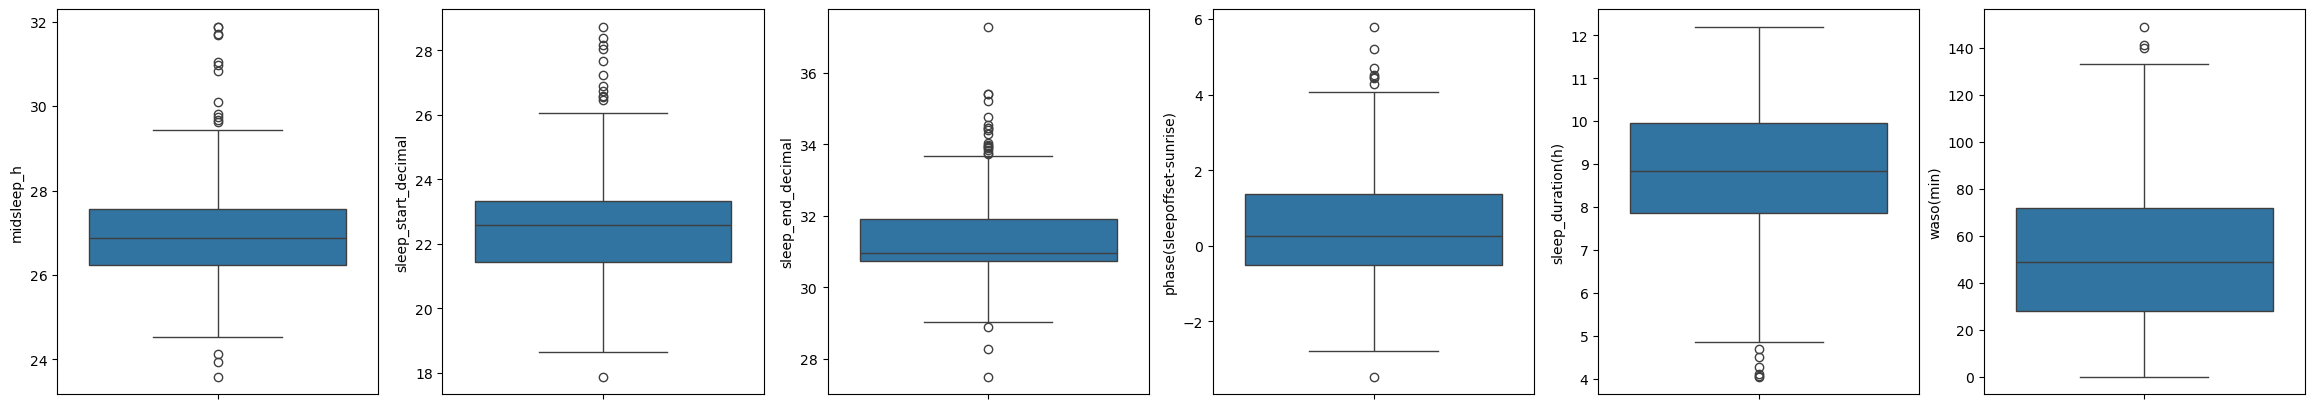

In [5]:
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [6]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [7]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime): return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [8]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [9]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [10]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)'] = df['sleep_duration(h)'].astype(float)
df['sleep_duration_work_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'free days')

In [11]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [12]:
# create a new df for weekly jetlag analysis
data_jetlag = df 

In [13]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week_of_year', 'weekday_type'])['midsleep_h'].mean().unstack()

In [14]:
# calculate the jet lag 
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [15]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

In [16]:
# rename columns
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})
df = df.rename(columns={'waso(min)': 'waso'})
df = df.rename(columns={'DST(0=ST)': 'DST_1'})

In [17]:
# dictionary with the season dates
seasons = {'Winter': [(12, 21), (3, 20)], 'Spring': [(3, 21), (6, 20)], 'Summer': [(6, 21), (9, 22)], 'Autumn': [(9, 23), (12, 20)]}

df['date'] = pd.to_datetime(df['date'])

In [18]:
# Function to get the season from the date
def get_season(date):
    month, day = date.month, date.day
    for season, ((start_month, start_day), (end_month, end_day)) in seasons.items():
        if (month == start_month and day >= start_day) or (month == end_month and day <= end_day):
            return season
        elif start_month < month < end_month:
            return season
    return 'Winter'  # for dates before 21st December and after 20th December

In [19]:
# Applying the function to create a season column
df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)
df.loc[:, 'season'] = df['date'].apply(get_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\2634099026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\2634099026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)


In [20]:
# new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [21]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [22]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [23]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [24]:
# add the index as a column
all_descriptive['variable'] = all_descriptive.index 

In [25]:
#reset the index
all_descriptive = all_descriptive.reset_index(drop=True)

In [26]:
all_descriptive.to_excel(fpath + '\\all_descriptive.xlsx')

In [27]:
#descriptive for workdays and freedays
workdays_descriptive = df_workdays.describe()
workdays_descriptive = workdays_descriptive.transpose()

# add the index as a column
workdays_descriptive['variable'] = workdays_descriptive.index

#reset the index
workdays_descriptive = workdays_descriptive.reset_index(drop=True)

In [28]:
# save the descriptive statistics for freedays
freedays_descriptive = df_freedays.describe()
freedays_descriptive = freedays_descriptive.transpose()

# add the index as a column
freedays_descriptive['variable'] = freedays_descriptive.index

#reset the index
freedays_descriptive = freedays_descriptive.reset_index(drop=True)

In [29]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()

In [30]:
descriptive_ita.to_excel(fpath + '\\descriptive_ita.xlsx')

In [31]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()

In [32]:
descriptive_uk.to_excel(fpath + '\\descriptive_uk.xlsx')

In [33]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [34]:
count_location

location
ITA    58.258258
UK     41.741742
Name: proportion, dtype: float64

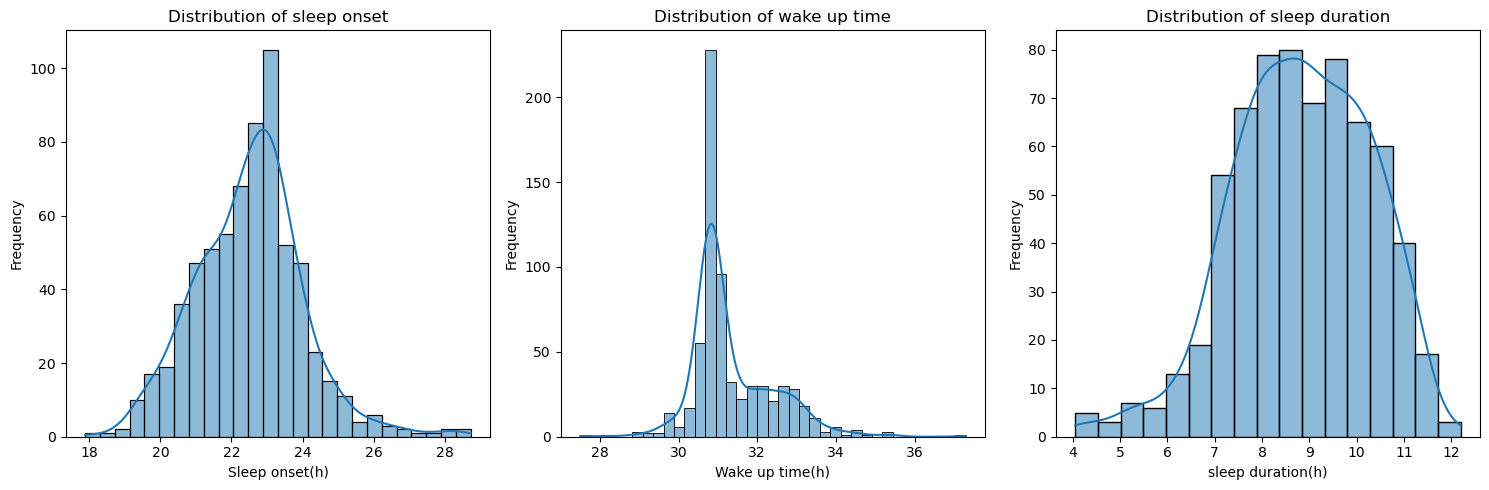

In [35]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal'].dropna(), kde=True)
plt.title("Distribution of wake up time")
plt.xlabel("Wake up time(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

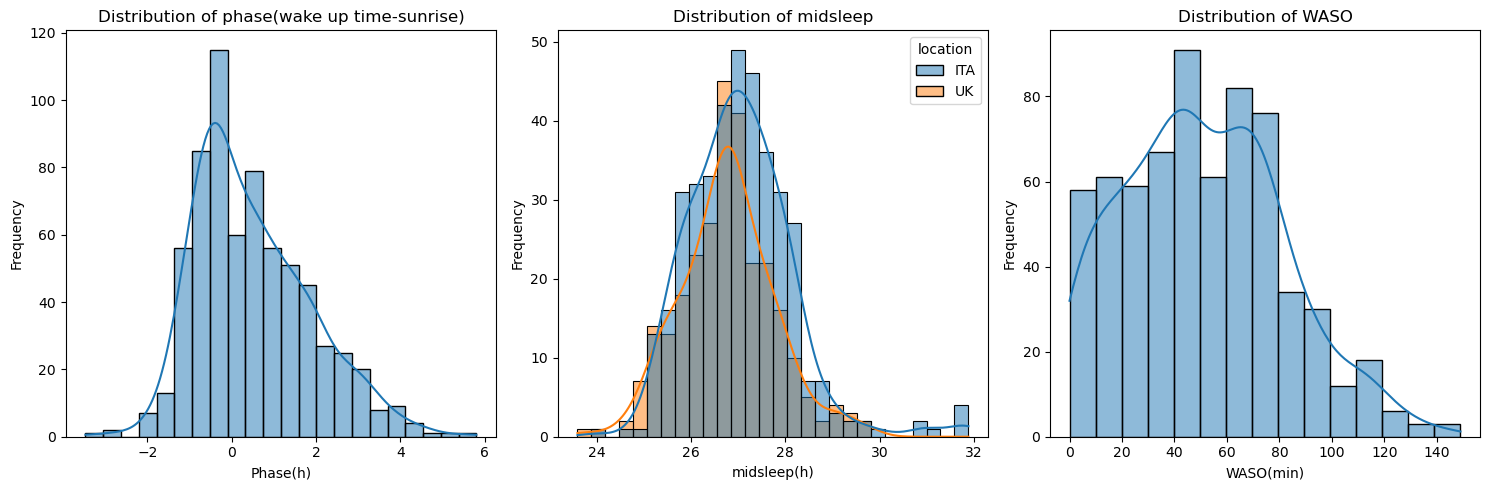

In [36]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(wake up time-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midsleep_h', kde=True, hue='location')
plt.title("Distribution of midsleep")
plt.xlabel("midsleep(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='waso', kde=True)
plt.title("Distribution of WASO")
plt.xlabel("WASO(min)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

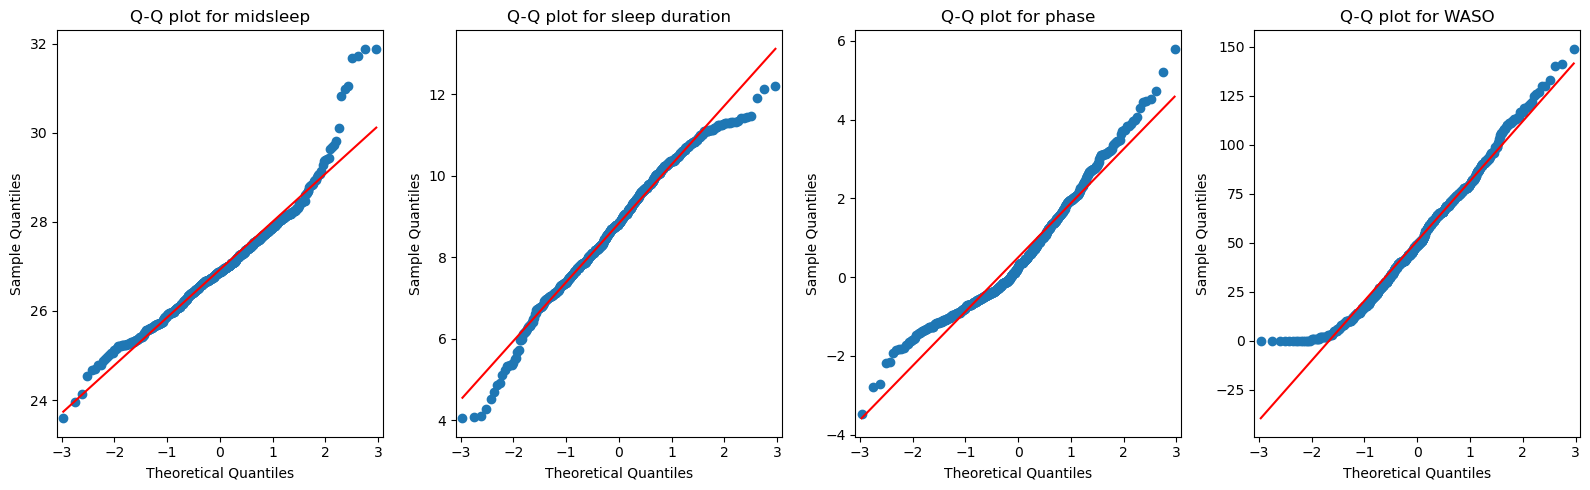

In [37]:
# Test normality by Q-Q plot
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

sm.qqplot(df['midsleep_h'].dropna(), line='s', ax=ax[0])
ax[0].set_title('Q-Q plot for midsleep')

sm.qqplot(df['sleep_duration'].dropna(), line='s', ax=ax[1])
ax[1].set_title('Q-Q plot for sleep duration')

sm.qqplot(df['phase'].dropna(), line='s', ax=ax[2])
ax[2].set_title('Q-Q plot for phase')

sm.qqplot(df['waso'].dropna(), line='s', ax=ax[3])
ax[3].set_title('Q-Q plot for WASO')

plt.tight_layout()
plt.show()


In [38]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration'])
shapiro_test_midsleep = stats.shapiro(df['midsleep_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase'])
shapiro_test_waso = stats.shapiro(df['waso'].dropna())

In [39]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration', 'midsleep_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)', 'waso(min)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midsleep, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase, shapiro_test_waso]
})

In [40]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration,"(0.9848850022350736, 2.21940674272492e-06)"
1,midsleep_h,"(0.9624510194180114, 5.0539796981387916e-12)"
2,sleep_start_decimal,"(0.9821700924977277, 2.9902087013896615e-07)"
3,sleep_end_decimal,"(0.881574446037927, 3.9483574809182507e-22)"
4,phase(sleepoffset-sunrise),"(0.9626282705791135, 5.474629945466521e-12)"
5,waso(min),"(0.9795681653958959, 5.630409812834638e-08)"


__Sleep-wake pattern between workdays and free days__

In [41]:
# descriptive statistics by location
df_grouped_weekdaytype = df.groupby('weekday_type').describe()

In [42]:
# compare variables between workdays and free days
# compare the variables between ITA and UK
ttest_midsleep_daytype = stats.ttest_ind(df[df['weekday_type'] == 'work days']['midsleep_h'], df[df['weekday_type'] == 'free days']['midsleep_h'])
ttest_duration_daytype = stats.ttest_ind(df[df['weekday_type'] == 'work days']['sleep_duration'], df[df['weekday_type'] == 'free days']['sleep_duration'])

utest_phase_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['phase'], df[df['weekday_type'] == 'free days']['phase'])
utest_start_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_start_decimal'], df[df['weekday_type'] == 'free days']['sleep_start_decimal'])
utest_end_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_end_decimal'], df[df['weekday_type'] == 'free days']['sleep_end_decimal'])
utest_waso_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['waso'].dropna(), df[df['weekday_type'] == 'free days']['waso'].dropna())

In [43]:
# print the results
print('T test results by day type')
print('T test midsleep:', ttest_midsleep_daytype)
print('T test duration:', ttest_duration_daytype)
print('U test results by day type')
print('U test phase:', utest_phase_daytype)
print('U test start:', utest_start_daytype)
print('U test end:', utest_end_daytype)
print('U test waso:', utest_waso_daytype)


T test results by day type
T test midsleep: TtestResult(statistic=-7.615055816859831, pvalue=9.093858113996217e-14, df=664.0)
T test duration: TtestResult(statistic=-3.1753579215872594, pvalue=0.001565754050608145, df=664.0)
U test results by day type
U test phase: MannwhitneyuResult(statistic=27894.0, pvalue=5.60152765531563e-14)
U test start: MannwhitneyuResult(statistic=35393.5, pvalue=3.316581048701907e-05)
U test end: MannwhitneyuResult(statistic=21926.0, pvalue=2.0579832845312918e-24)
U test waso: MannwhitneyuResult(statistic=35729.0, pvalue=0.0002669390867751625)


__Sleep-wake pattern between Uk and Italy__

In [44]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [45]:
# compare the variables between ITA and UK
ttest_midsleep_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midsleep_h'], df[df['location'] == 'UK']['midsleep_h'])
ttest_duration_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_duration'], df[df['location'] == 'UK']['sleep_duration'])

utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal'], df[df['location'] == 'UK']['sleep_start_decimal'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal'], df[df['location'] == 'UK']['sleep_end_decimal'])
utest_waso_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['waso'].dropna(), df[df['location'] == 'UK']['waso'].dropna())

In [46]:
# print the results
print('T test results by location')
print('Midsleep_all:', ttest_midsleep_all_loc)
print('Sleep_duration:', ttest_duration_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Phase:', utest_phase_loc)
print('WASO:', utest_waso_loc)

T test results by location
Midsleep_all: TtestResult(statistic=3.1967759199204635, pvalue=0.0014556640965908442, df=664.0)
Sleep_duration: TtestResult(statistic=-0.6826135588013178, pvalue=0.4950891344799263, df=664.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=59760.0, pvalue=0.017313332694237512)
Sleep_offset: MannwhitneyuResult(statistic=62690.0, pvalue=0.0003479759888140954)
Phase: MannwhitneyuResult(statistic=54873.0, pvalue=0.7009016518533244)
WASO: MannwhitneyuResult(statistic=41511.0, pvalue=1.5940348188153738e-06)


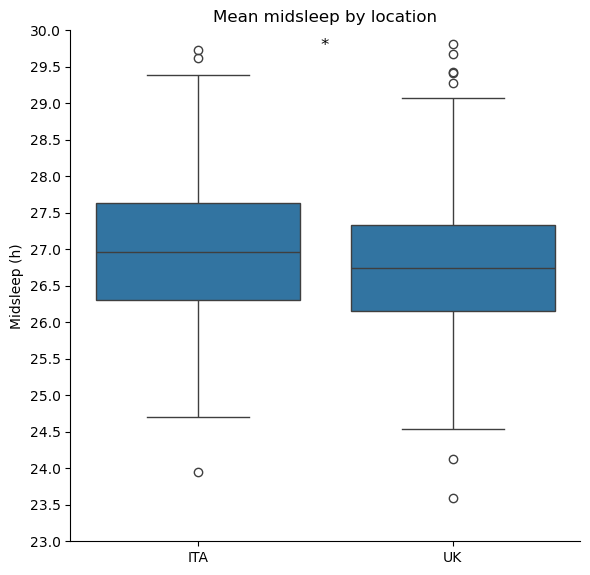

In [47]:
# plot the midpoint of sleep by location
plt.figure(figsize=(6, 6))
sns.boxplot(x='location', y='midsleep_h', data=df)
plt.title('Mean midsleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midsleep (h)')
plt.ylim(23, 30)
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.5)) # gcd stands for 'get current axis'
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

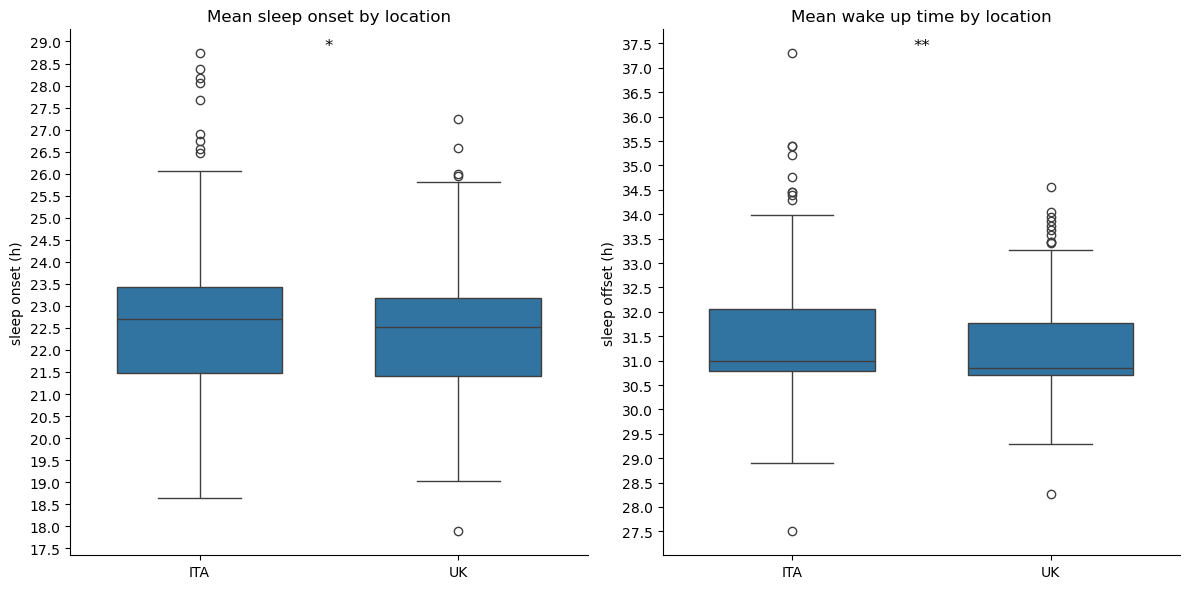

In [48]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h)')
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal', data=df, gap=0.2)
plt.title('Mean wake up time by location')
plt.xlabel('')
plt.ylabel('sleep offset (h)')
plt.annotate('**', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

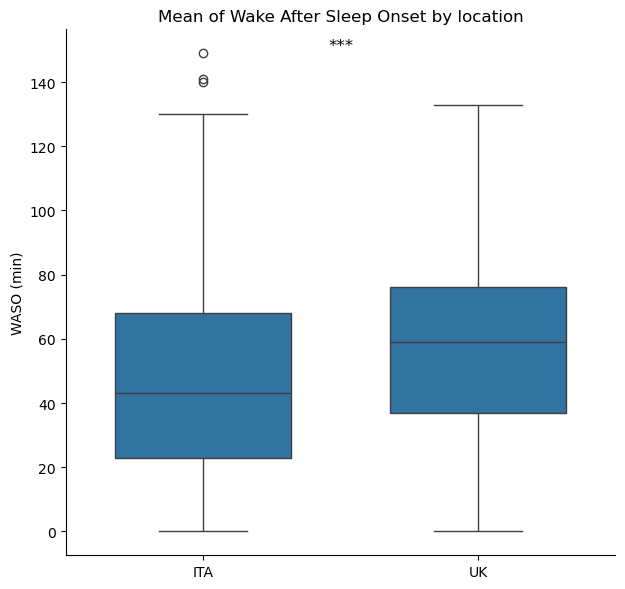

In [49]:
# plot the waso by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='waso', data=df, gap=0.2)
plt.title('Mean of Wake After Sleep Onset by location')
plt.xlabel('')
plt.ylabel('WASO (min)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
#plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

__Jet lag__

In [50]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag['jet lag'].dropna()

In [51]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [52]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9876125382572299, pvalue=0.4370184776875048)


In [53]:
# test the difference in jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), 
                               weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

In [54]:
print('T test result for jet lag by location:')
print(ttest_jetlag)

T test result for jet lag by location:
TtestResult(statistic=-0.744182642873099, pvalue=0.45844414182344906, df=104.0)


__Season and sleep-wake pattern__

In [55]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration']) 
df2 = df.dropna(subset=['phase'])
df3 = df.dropna(subset=['waso'])

In [56]:
anova_ols_midsleep_season = ols('midsleep_h ~ C(season)', data=df).fit() # generate and fit the regression model
anova_results_midsleep = sm.stats.anova_lm(anova_ols_midsleep_season, typ=3) # fit the ANOVA model and get the results

In [57]:
print('ANOVA Result for midsleep:')
print(anova_results_midsleep)

ANOVA Result for midsleep:
                  sum_sq     df              F    PR(>F)
Intercept  186626.067365    1.0  162360.576817  0.000000
C(season)       7.496111    3.0       2.173817  0.089882
Residual      760.938764  662.0            NaN       NaN


In [58]:
anova_sleep_duration_season = ols('sleep_duration ~ C(season)', data=df1).fit()
anova_results_sleep_duration = sm.stats.anova_lm(anova_sleep_duration_season, typ=3)

print('ANOVA Result for sleep duration:')
print(anova_results_sleep_duration)

ANOVA Result for sleep duration:
                 sum_sq     df            F    PR(>F)
Intercept  18684.482667    1.0  9131.619328  0.000000
C(season)     32.027700    3.0     5.217605  0.001448
Residual    1354.538235  662.0          NaN       NaN


In [59]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df1['sleep_duration'], df1['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.4642  0.023  0.0453 0.8832   True
Autumn Summer   0.3848 0.0655 -0.0163  0.786  False
Autumn Winter   0.4791 0.0039  0.1168 0.8414   True
Spring Summer  -0.0794  0.974  -0.559 0.4002  False
Spring Winter   0.0149 0.9998 -0.4327 0.4624  False
Summer Winter   0.0943 0.9429 -0.3367 0.5252  False
---------------------------------------------------


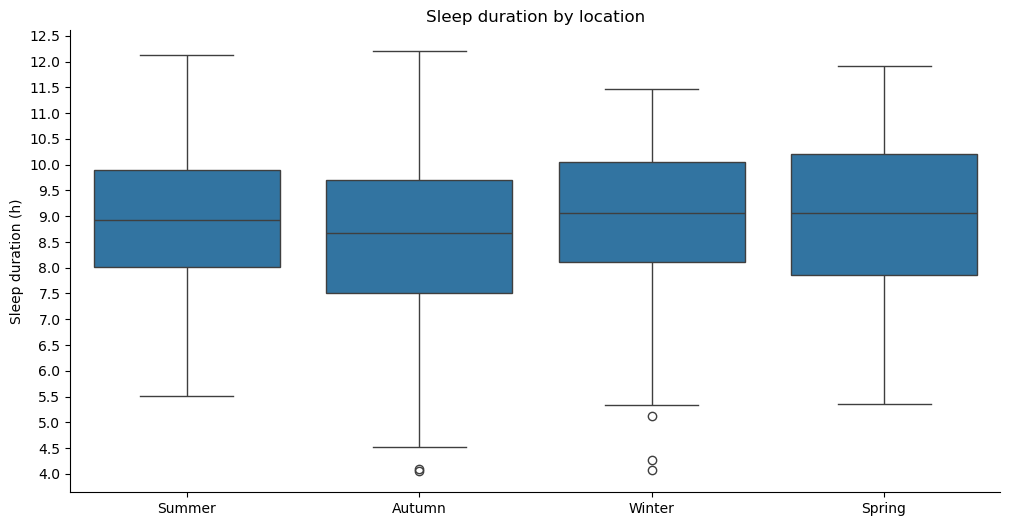

In [60]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration', data=df1)
plt.title('Sleep duration by location')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [61]:
# perform a Kruskal-Wallis test to compare the phase, sleep end and waso between the seasons
kw_phase_season = stats.kruskal(df2[df2['season'] == 'Winter']['phase'], df2[df2['season'] == 'Spring']['phase'], 
                                df2[df2['season'] == 'Summer']['phase'], df2[df2['season'] == 'Autumn']['phase'])

kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal'], df[df['season'] == 'Spring']['sleep_start_decimal'], 
                              df[df['season'] == 'Summer']['sleep_start_decimal'], df[df['season'] == 'Autumn']['sleep_start_decimal'])

kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal'], df[df['season'] == 'Spring']['sleep_end_decimal'], 
                              df[df['season'] == 'Summer']['sleep_end_decimal'], df[df['season'] == 'Autumn']['sleep_end_decimal'])

kw_waso_season = stats.kruskal(df3[df3['season'] == 'Winter']['waso'], df3[df3['season'] == 'Spring']['waso'], 
                               df3[df3['season'] == 'Summer']['waso'], df3[df3['season'] == 'Autumn']['waso'])

print('Kruskal-Wallis test results for phase:')
print(kw_phase_season)
print('Kruskal-Wallis test results for sleep start:')
print(kw_start_season)
print('Kruskal-Wallis test results for sleep end:')
print(kw_end_season)
print('Kruskal-Wallis test results for waso:')  
print(kw_waso_season)

Kruskal-Wallis test results for phase:
KruskalResult(statistic=239.20430617422772, pvalue=1.4144049850108187e-51)
Kruskal-Wallis test results for sleep start:
KruskalResult(statistic=8.267619534162204, pvalue=0.040792794193028725)
Kruskal-Wallis test results for sleep end:
KruskalResult(statistic=3.5986530047656777, pvalue=0.30819075034843046)
Kruskal-Wallis test results for waso:
KruskalResult(statistic=3.381088116126334, pvalue=0.3365152056949655)


In [62]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df2['phase'], df2['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.6327    0.0   1.301  1.9643   True
Autumn Summer   1.6302    0.0  1.3126  1.9478   True
Autumn Winter  -0.0262 0.9954 -0.3129  0.2606  False
Spring Summer  -0.0025    1.0 -0.3821  0.3772  False
Spring Winter  -1.6588    0.0 -2.0131 -1.3046   True
Summer Winter  -1.6564    0.0 -1.9975 -1.3152   True
----------------------------------------------------


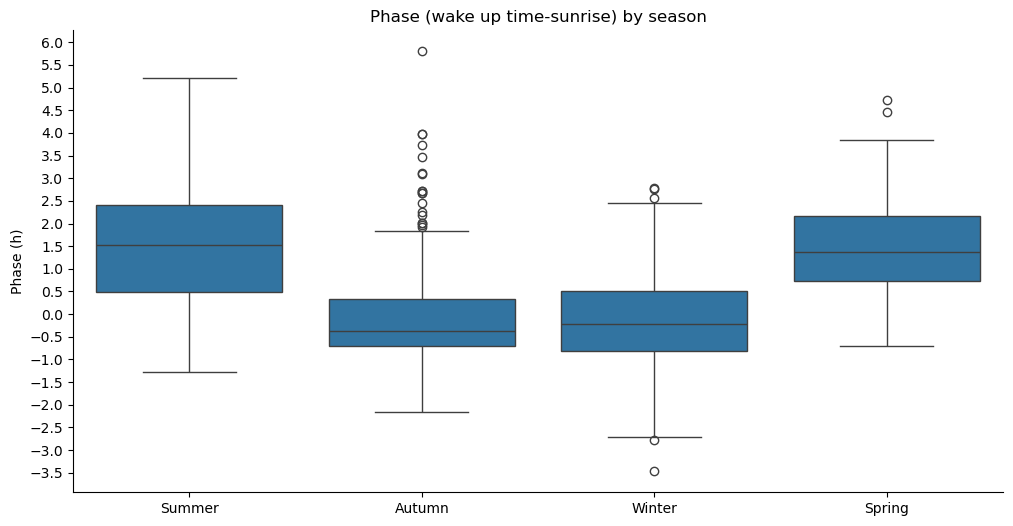

In [63]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__DST and sleep-wake pattern__

In [64]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_midsleep_dst = stats.ttest_ind(df[df['DST_1'] == 0]['midsleep_h'], df[df['DST_1'] == 1]['midsleep_h'])
ttest_sleep_duration_dst = stats.ttest_ind(df1[df1['DST_1'] == 0]['sleep_duration'], df1[df1['DST_1'] == 1]['sleep_duration'])

utest_sleep_start_dst = stats.mannwhitneyu(df[df['DST_1'] == 0]['sleep_start_decimal'], df[df['DST_1'] == 1]['sleep_start_decimal'])
utest_sleep_end_dst = stats.mannwhitneyu(df[df['DST_1'] == 0]['sleep_end_decimal'], df[df['DST_1'] == 1]['sleep_end_decimal'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_1'] == 0]['phase'], df2[df2['DST_1'] == 1]['phase'])
utest_waso_dst = stats.mannwhitneyu(df3[df3['DST_1'] == 0]['waso'], df3[df3['DST_1'] == 1]['waso'])

In [65]:
print('T test result for the midsleep by DST:')
print(ttest_midsleep_dst)
print('T test result for the sleep duration by DST:')
print(ttest_sleep_duration_dst)
print('U test result for the sleep onset by DST:')
print(utest_sleep_start_dst)
print('U test result for the sleep offset by DST:')
print(utest_sleep_end_dst)
print('U test result for the phase by DST:')
print(utest_phase_dst)
print('U test result for the waso by DST:')
print(utest_waso_dst)

T test result for the midsleep by DST:
TtestResult(statistic=0.3135544024327143, pvalue=0.7539579681491707, df=664.0)
T test result for the sleep duration by DST:
TtestResult(statistic=0.4852074207569695, pvalue=0.6276892607051074, df=664.0)
U test result for the sleep onset by DST:
MannwhitneyuResult(statistic=53242.5, pvalue=0.3756350266641778)
U test result for the sleep offset by DST:
MannwhitneyuResult(statistic=56990.0, pvalue=0.533185574604567)
U test result for the phase by DST:
MannwhitneyuResult(statistic=28929.5, pvalue=1.2724926482140772e-26)
U test result for the waso by DST:
MannwhitneyuResult(statistic=54506.5, pvalue=0.9649050411931701)


In [66]:
# mean and standard deviation of the phase by DST
df_grouped_dst = df.groupby('DST_1').agg({'phase': ['mean', 'std']})
df_grouped_dst = df_grouped_dst.reset_index()
df_grouped_dst.columns = ['DST', 'mean', 'std']

df_grouped_dst

,DST,mean,std
0,0,-0.043328,1.177551
1,1,1.040473,1.348484


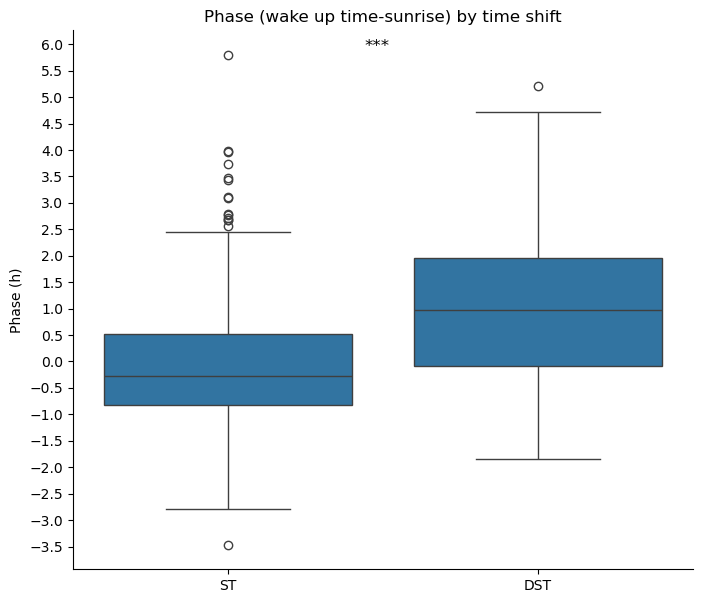

In [67]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(8, 7))
sns.boxplot(x='DST_1', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by time shift')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['ST', 'DST'])
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('***', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__Photoperiod and sleep-wake pattern__

In [68]:
# correlation between sleep-wake variables and photoperiod
correlation1_test1 = stats.pearsonr(df['midsleep_h'], df['photoperiod'])
correlation1_test2 = stats.pearsonr(df_workdays['midsleep_h'], df_workdays['photoperiod'])
correlation1_test3 = stats.pearsonr(df_freedays['midsleep_h'], df_freedays['photoperiod'])
correlation1_test4 = stats.pearsonr(df2['sleep_duration'], df2['photoperiod'])

# correlation between sleep-wake variables and photoperiod using Spearman's rank correlation
correlation1_test5 = stats.spearmanr(df['sleep_start_decimal'], df['photoperiod'])
correlation1_test6 = stats.spearmanr(df['sleep_end_decimal'], df['photoperiod'])
correlation1_test7 = stats.spearmanr(df3['waso'], df3['photoperiod'])

In [69]:
# extract the coefficients and p-values from the correlation test results
correlation1_coeff = [correlation1_test1.statistic, correlation1_test2.statistic, correlation1_test3.statistic, 
                     correlation1_test4.statistic, correlation1_test5.statistic, correlation1_test6.statistic,
                     correlation1_test7.statistic]

p_values = [correlation1_test1.pvalue, correlation1_test2.pvalue, correlation1_test3.pvalue, 
            correlation1_test4.pvalue, correlation1_test5.pvalue, correlation1_test6.pvalue,
            correlation1_test7.pvalue]

In [70]:
# create a DataFrame with the results
correlation1_results = pd.DataFrame({
    'Variables': ['midsleep vs photoperiod', 'midsleep (w) vs photoperiod', 'midsleep (f) vs photoperiod', 
                  'sleep duration vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod', 'WASO(min) vs photoperiod'],
    'Coefficient': correlation1_coeff,
    'P-value': p_values
})

correlation1_results

,Variables,Coefficient,P-value
0,midsleep vs photoperiod,-0.051302,0.186061
1,midsleep (w) vs photoperiod,-0.076994,0.091999
2,midsleep (f) vs photoperiod,-0.003931,0.957531
3,sleep duration vs photoperiod,0.054189,0.162459
4,sleep onset vs photoperiod,-0.022664,0.559316
5,sleep offset vs photoperiod,-0.018105,0.640940
6,WASO(min) vs photoperiod,0.035022,0.368664


In [71]:
# correlation between sleep-wake variables and photoperiod
correlation2_test1 = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
correlation2_test2 = stats.pearsonr(df_workdays['midsleep_h_UTC'], df_workdays['photoperiod'])
correlation2_test3 = stats.pearsonr(df_freedays['midsleep_h_UTC'], df_freedays['photoperiod'])
correlation2_test4 = stats.pearsonr(df2['sleep_duration'], df2['photoperiod'])

# correlation between sleep-wake variables and photoperiod using Spearman's rank correlation
correlation2_test5 = stats.spearmanr(df['sleep_start_decimal_UTC'], df['photoperiod'])
correlation2_test6 = stats.spearmanr(df['sleep_end_decimal_UTC'], df['photoperiod'])
correlation2_test7 = stats.spearmanr(df3['waso'], df3['photoperiod'])

In [72]:
# extract the coefficients and p-values from the correlation test results
correlation2_coeff = [correlation2_test1.statistic, correlation2_test2.statistic, correlation2_test3.statistic, 
                     correlation2_test4.statistic, correlation2_test5.statistic, correlation2_test6.statistic,
                     correlation2_test7.statistic]

p_values = [correlation2_test1.pvalue, correlation2_test2.pvalue, correlation2_test3.pvalue, 
            correlation2_test4.pvalue, correlation2_test5.pvalue, correlation2_test6.pvalue,
            correlation2_test7.pvalue]

In [73]:
# create a DataFrame with the results
correlation2_results = pd.DataFrame({
    'Variables': ['midsleep vs photoperiod', 'midsleep (w) vs photoperiod', 'midsleep (f) vs photoperiod', 
                  'sleep duration vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod', 'WASO(min) vs photoperiod'],
    'Coefficient': correlation2_coeff,
    'P-value': p_values
})

correlation2_results

,Variables,Coefficient,P-value
0,midsleep vs photoperiod,-0.367169,1.102054e-22
1,midsleep (w) vs photoperiod,-0.395167,2.172850e-19
2,midsleep (f) vs photoperiod,-0.341959,1.778696e-06
3,sleep duration vs photoperiod,0.054189,1.624592e-01
4,sleep onset vs photoperiod,-0.312740,1.409988e-16
5,sleep offset vs photoperiod,-0.378014,4.749661e-24
6,WASO(min) vs photoperiod,0.035022,3.686640e-01


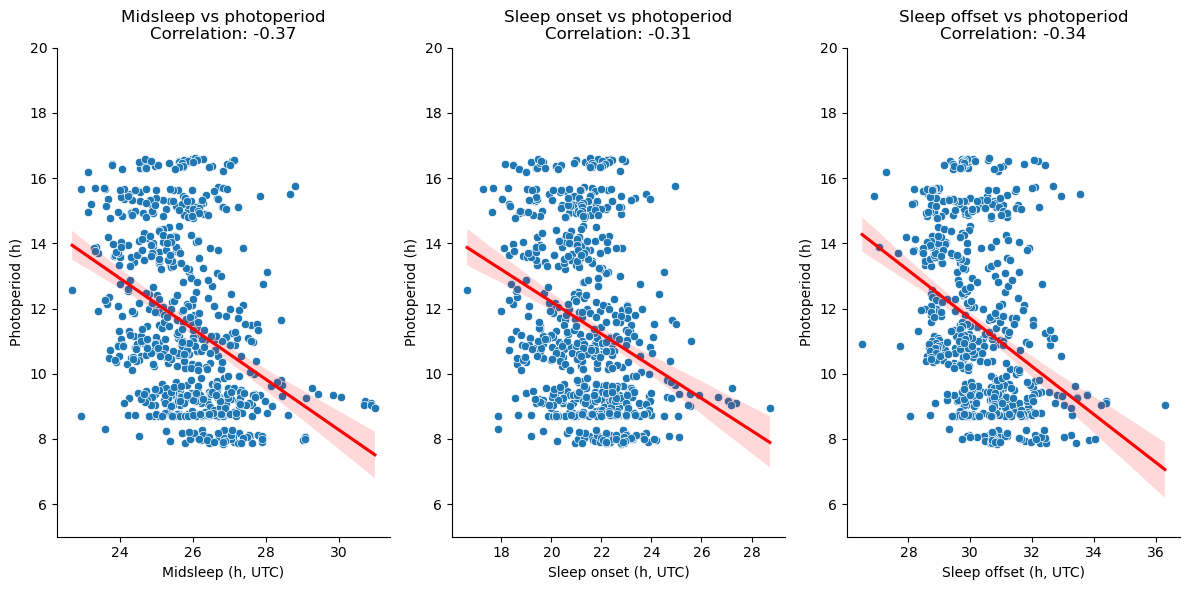

In [74]:
# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x='midsleep_h_UTC', y='photoperiod', data=df)
sns.regplot(x='midsleep_h_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_all, _ = stats.pearsonr(df['midsleep_h_UTC'], df['photoperiod'])
plt.title(f'Midsleep vs photoperiod\nCorrelation: {corr_all:.2f}')
plt.xlabel('Midsleep (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 3, 2)
sns.scatterplot(x='sleep_start_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_start_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_free, _ = stats.pearsonr(df['sleep_start_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep onset vs photoperiod\nCorrelation: {corr_free:.2f}')
plt.xlabel('Sleep onset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 3, 3)
sns.scatterplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df)
sns.regplot(x='sleep_end_decimal_UTC', y='photoperiod', data=df, scatter=False, color='red')
corr_offset, _ = stats.pearsonr(df['sleep_end_decimal_UTC'], df['photoperiod'])
plt.title(f'Sleep offset vs photoperiod\nCorrelation: {corr_offset:.2f}')
plt.xlabel('Sleep offset (h, UTC)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.tight_layout()
plt.show()

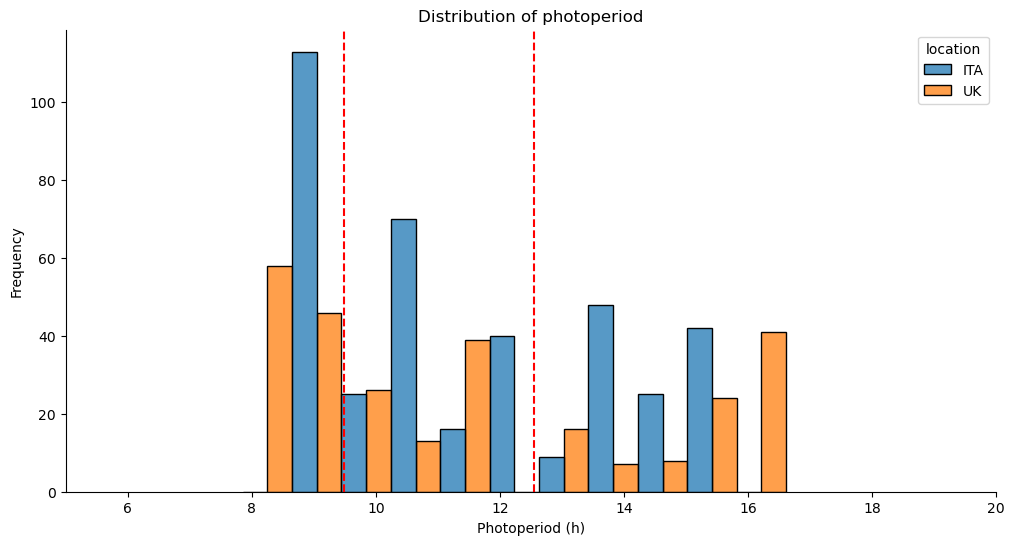

In [75]:
# distribution of the photoperiod
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='photoperiod', kde=False, hue='location', multiple='dodge')
plt.title('Distribution of photoperiod')
plt.xlabel('Photoperiod (h)')
plt.ylabel('Frequency')

# Add vertical lines for the tertiles
tertiles = df['photoperiod'].quantile([1/3, 2/3])
for tertile in tertiles:
    plt.axvline(tertile, color='r', linestyle='--')

plt.xlim(5, 20)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.show()

In [76]:
# define the tertile of the photoperiod
df['photoperiod_tertile'] = pd.qcut(df['photoperiod'], 3, labels=['short', 'medium', 'long'])
df2['photoperiod_tertile'] = pd.qcut(df2['photoperiod'], 3, labels=['short', 'medium', 'long'])
df3['photoperiod_tertile'] = pd.qcut(df3['photoperiod'], 3, labels=['short', 'medium', 'long'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\2368887206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['photoperiod_tertile'] = pd.qcut(df3['photoperiod'], 3, labels=['short', 'medium', 'long'])


In [77]:
# how many observations are in each tertile
tertile_counts = df['photoperiod_tertile'].value_counts()

tertile_counts

photoperiod_tertile
short     222
medium    222
long      222
Name: count, dtype: int64

In [78]:
# descriptive statistics by photoperiod tertile
df_grouped_photoperiod = df.groupby('photoperiod_tertile').describe()
df_grouped_photoperiod = df_grouped_photoperiod.transpose()

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\3606957749.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_photoperiod = df.groupby('photoperiod_tertile').describe()


In [79]:
# define different df for the 3 photoperiod tertiles
df_short = df[df['photoperiod_tertile'] == 'short']
df_medium = df[df['photoperiod_tertile'] == 'medium']
df_long = df[df['photoperiod_tertile'] == 'long']

In [80]:
# ttest between Ita and UK photoperiod in shorter photoperiod
ttest_midsleep_short = stats.ttest_ind(df_short[df_short['location'] == 'ITA']['midsleep_h'], df_short[df_short['location'] == 'UK']['midsleep_h'])
ttest_duration_short = stats.ttest_ind(df_short[df_short['location'] == 'ITA']['sleep_duration'], df_short[df_short['location'] == 'UK']['sleep_duration'])

utest_phase_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['phase'], df_short[df_short['location'] == 'UK']['phase'])
utest_start_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['sleep_start_decimal'], df_short[df_short['location'] == 'UK']['sleep_start_decimal'])
utest_end_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['sleep_end_decimal'], df_short[df_short['location'] == 'UK']['sleep_end_decimal'])
utest_waso_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['waso'].dropna(), df_short[df_short['location'] == 'UK']['waso'].dropna())

In [81]:
# print the results
print('T test results by location for shorter photoperiod')
print('Midsleep:', ttest_midsleep_short)
print('Sleep duration:', ttest_duration_short)
print('U test results by location for shorter photoperiod')
print('Phase:', utest_phase_short)
print('Sleep onset:', utest_start_short)
print('Sleep offset:', utest_end_short)
print('WASO:', utest_waso_short)

T test results by location for shorter photoperiod
Midsleep: TtestResult(statistic=2.421471016267581, pvalue=0.01626833364067653, df=220.0)
Sleep duration: TtestResult(statistic=0.4705265730502681, pvalue=0.638445001481827, df=220.0)
U test results by location for shorter photoperiod
Phase: MannwhitneyuResult(statistic=7203.0, pvalue=0.02738486097189133)
Sleep onset: MannwhitneyuResult(statistic=6486.0, pvalue=0.480155777386273)
Sleep offset: MannwhitneyuResult(statistic=7691.5, pvalue=0.0012463011826794425)
WASO: MannwhitneyuResult(statistic=5027.0, pvalue=0.024567213842032254)


In [82]:
# test between Ita and UK photoperiod in longer photoperiod
ttest_long_midsleep = stats.ttest_ind(df_long[df_long['location'] == 'ITA']['midsleep_h'], df_long[df_long['location'] == 'UK']['midsleep_h'])
ttest_long_sleep_duration = stats.ttest_ind(df_long[df_long['location'] == 'ITA']['sleep_duration'], df_long[df_long['location'] == 'UK']['sleep_duration'])

utest_long_phase = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['phase'], df_long[df_long['location'] == 'UK']['phase'])
utest_long_start = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['sleep_start_decimal'], df_long[df_long['location'] == 'UK']['sleep_start_decimal'])
utest_long_end = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['sleep_end_decimal'], df_long[df_long['location'] == 'UK']['sleep_end_decimal'])
utest_long_waso = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['waso'].dropna(), df_long[df_long['location'] == 'UK']['waso'].dropna())

In [83]:
#print the results
print('T test results for longer photoperiod:')
print('T test midsleep:', ttest_long_midsleep)
print('T test sleep duration:', ttest_long_sleep_duration)
print('U test results for longer photoperiod:')
print('U test phase:', utest_long_phase)
print('U test sleep onset:', utest_long_start)
print('U test sleep offset:', utest_long_end)
print('U test waso:', utest_long_waso)

T test results for longer photoperiod:
T test midsleep: TtestResult(statistic=2.2887399527014174, pvalue=0.023043671625895632, df=220.0)
T test sleep duration: TtestResult(statistic=-1.8545574432126575, pvalue=0.06499762035540738, df=220.0)
U test results for longer photoperiod:
U test phase: MannwhitneyuResult(statistic=4729.0, pvalue=0.005419489793550682)
U test sleep onset: MannwhitneyuResult(statistic=7418.0, pvalue=0.0038697534083831455)
U test sleep offset: MannwhitneyuResult(statistic=6790.5, pvalue=0.11756292094274318)
U test waso: MannwhitneyuResult(statistic=4282.5, pvalue=0.0005436209171242682)


In [84]:
# bonferroni correction
alpha = 0.001
n_tests = 12
alpha_corrected = alpha / n_tests

alpha_corrected

8.333333333333333e-05

In [85]:
# mean and standard deviation of the sleep var by photoperiod tertile and location
midsleep_phot_loc = df.groupby(['photoperiod_tertile', 'location']).agg({'midsleep_h': ['mean', 'std'], 'sleep_start_decimal': ['mean', 'std'], 
                                                                             'phase': ['mean', 'std'], 'waso': ['mean', 'std']})
midsleep_phot_loc = midsleep_phot_loc.reset_index()
midsleep_phot_loc.columns = ['Photoperiod', 'Location', 'Mean midsleep', 'Std midsleep', 'Mean sleep onset', 'Std sleep onset', 
                                  'Mean phase', 'Std phase', 'Mean WASO', 'Std WASO']

midsleep_phot_loc

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\380355584.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  midsleep_phot_loc = df.groupby(['photoperiod_tertile', 'location']).agg({'midsleep_h': ['mean', 'std'], 'sleep_start_decimal': ['mean', 'std'],


,Photoperiod,Location,Mean midsleep,Std midsleep,Mean sleep onset,Std sleep onset,Mean phase,Std phase,Mean WASO,Std WASO
0,short,ITA,27.213901,1.427128,22.780532,1.875084,-0.019397,1.375445,48.269565,30.143319
1,short,UK,26.822288,0.897009,22.434355,1.247134,-0.432704,1.003138,55.849057,27.743997
2,medium,ITA,26.940868,0.909524,22.586073,1.408552,0.113128,0.970374,43.205479,28.183614
3,medium,UK,26.821820,1.032962,22.499013,1.694002,0.063487,0.856067,53.200000,33.532961
4,long,ITA,26.991799,0.986112,22.566601,1.340493,1.432870,1.096485,48.580645,32.767497
5,long,UK,26.673741,1.075746,22.078819,1.417564,1.879687,1.228039,62.494737,28.168518


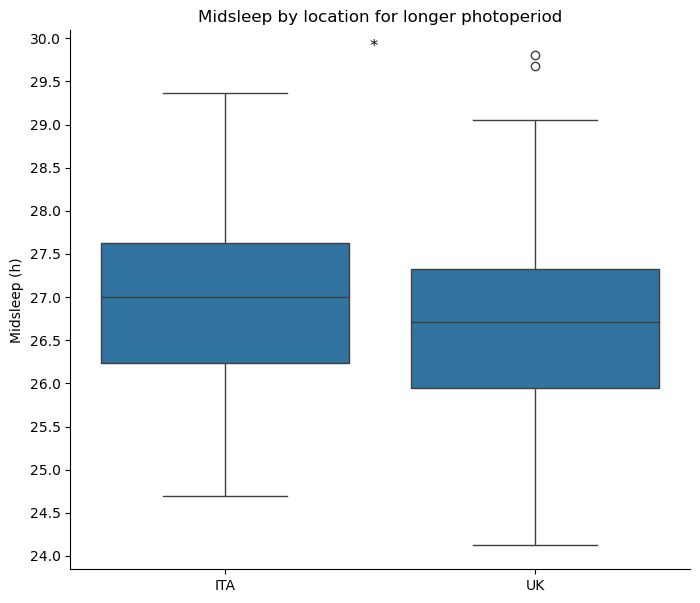

In [86]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='midsleep_h', data=df_long)
plt.title('Midsleep by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Midsleep (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

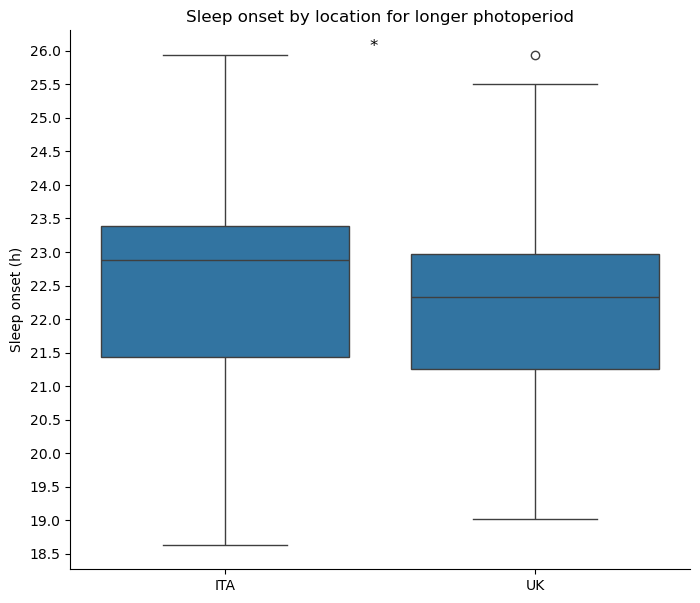

In [87]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='sleep_start_decimal', data=df_long)
plt.title('Sleep onset by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep onset (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

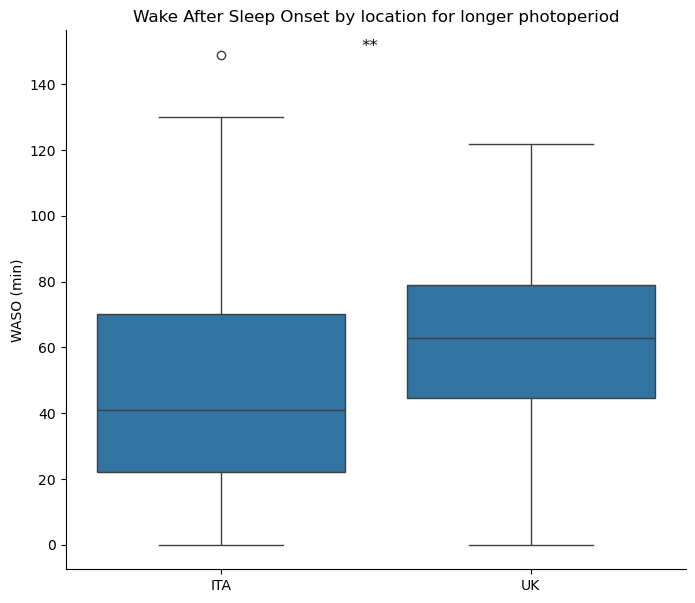

In [88]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='waso', data=df_long)
plt.title('Wake After Sleep Onset by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('WASO (min)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.annotate('**', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

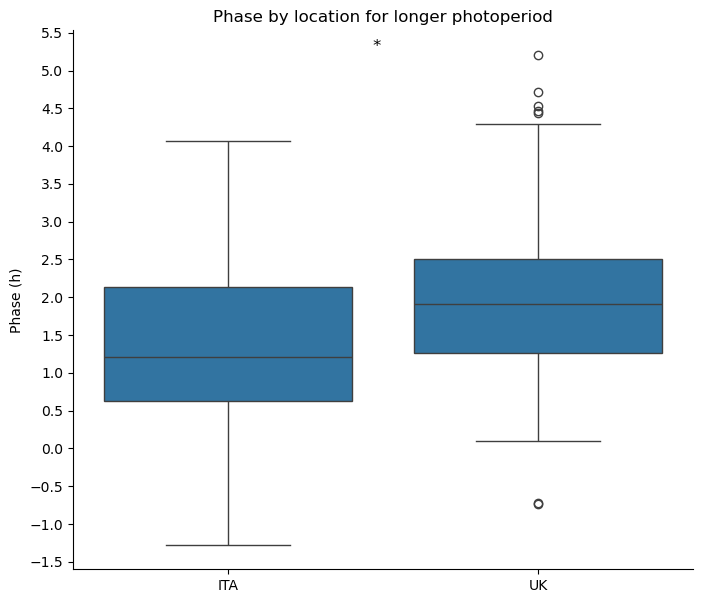

In [89]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='phase', data=df_long)
plt.title('Phase by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__Weekly IV, IS and RA__

In [90]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag

In [91]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [92]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [93]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [94]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag,location
0,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,26.491667,27.608333,-1.116667,ITA
1,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,27.766670,26.637500,1.129170,UK
2,42,2022-10-19 to 2022-10-25,0.592888,0.086393,0.934961,2022-10-19,2022-10-25,25.385417,26.045000,-0.659583,UK
3,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,26.570833,28.237500,-1.666667,ITA
4,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,24.129167,26.030208,-1.901042,UK


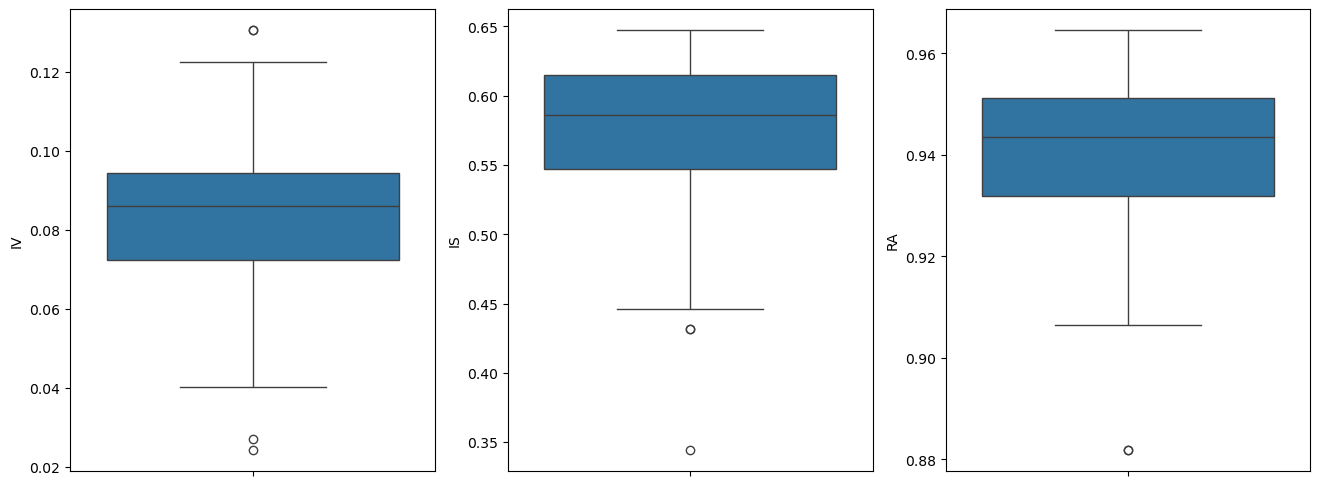

In [95]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [96]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()

summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       63.0  0.081875  0.021206  0.024172  0.068838  0.084375  0.093261   
UK        45.0  0.087831  0.016381  0.053677  0.075640  0.086685  0.097674   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  58.0  0.576607  ...  0.615054  0.647358  60.0  0.942044   
UK        0.130562  43.0  0.572043  ...  0.612777  0.645810  43.0  0.938983   

                                                                      
               std       min       25%       50%       75%       max  
location                                                              
ITA       0.015210  0.881815  0.932905  0.943610  0.951849  0.964584  
UK        0.016212  0.881815  0.931148  0.942958  0.948727  0.962952  

[2 rows x 24 columns]

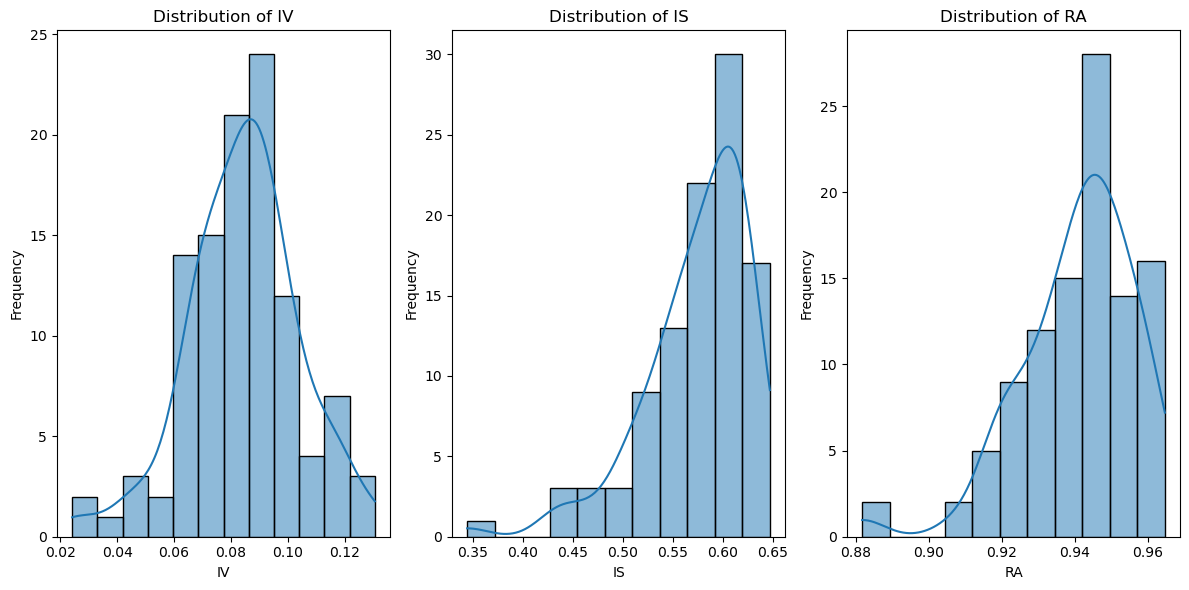

In [97]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [98]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [99]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_utest)
print('Test results for RA by location:', ra_utest)

Test results for IV by location: TtestResult(statistic=-1.5767935413484517, pvalue=0.11782288955003352, df=106.0)
Test results for IS by location: MannwhitneyuResult(statistic=1317.0, pvalue=0.6330928748997473)
Test results for RA by location: MannwhitneyuResult(statistic=1434.0, pvalue=0.33719076262194314)


------------------------

__Sleep-wake patterns over time__

In [100]:
# filter df to have only day_after_flight 1,2,8,9
df_flight1 = df[df['day_after_flight'].isin([1, 2, 8, 9])]

In [101]:
# new column with the day after flight day 1 and 2 as '0' and day 8 and 9 as '1'
df_flight1['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight1['day_after_flight'].isin([1, 2]), '0', '1')

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\3185984710.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_flight1['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight1['day_after_flight'].isin([1, 2]), '0', '1')


In [102]:
# rename df_flight1['day_after_flight_group(0=day1&2;1=day8&9)']
df_flight1 = df_flight1.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

In [103]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
df = df[(np.abs(stats.zscore(df['midsleep_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_duration'])) < 3)]

In [104]:
# filter df to have only day_after_flight > 15
#df = df[df['day_after_flight'] > 15] 

_Sleep onset_

In [105]:
model1 = smf.mixedlm('sleep_start_decimal ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model1.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sleep_start_decimal
No. Observations: 644     Method:             REML               
No. Groups:       47      Scale:              1.7176             
Min. group size:  1       Log-Likelihood:     -1105.9219         
Max. group size:  46      Converged:          Yes                
Mean group size:  13.7                                           
------------------------------------------------------------------
                  Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept         22.331     0.101  221.347  0.000  22.133  22.529
day_after_flight   0.007     0.009    0.758  0.448  -0.011   0.024
Group Var          0.100     0.038                                



In [106]:
model2 = smf.mixedlm('sleep_start_decimal ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    sleep_start_decimal
No. Observations:     644        Method:                REML               
No. Groups:           47         Scale:                 1.7058             
Min. group size:      1          Log-Likelihood:        -1107.1196         
Max. group size:      46         Converged:             Yes                
Mean group size:      13.7                                                 
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       22.352    0.132 168.921 0.000 22.092 22.611
location[T.UK]                   0.146    0.219   0.665 0.506 -0.284  0.576
day_after_flight                 0.013    0.010   1.344 0.179 -0.006  0.032
location[T.UK]:day_after_flight

In [107]:
# shapiro-wilk test for sleep_start_decimal
shapiro_test_sleep_start = stats.shapiro(df_flight1['sleep_start_decimal'])

shapiro_test_sleep_start

ShapiroResult(statistic=0.9817985257202096, pvalue=0.01945454014587061)

In [108]:
ttest_start_days = stats.ttest_ind(df_flight1[df_flight1['day_after_flight_group'] == '0']['sleep_start_decimal'], df_flight1[df_flight1['day_after_flight_group'] == '1']['sleep_start_decimal'])

ttest_start_days

TtestResult(statistic=2.1567840251111763, pvalue=0.03237143176370836, df=177.0)

In [109]:
# mean and std of sleep_start_decimal by day_after_flight_group 
df_grouped_flight = df_flight1.groupby(['day_after_flight_group']).agg({'sleep_start_decimal': ['mean', 'std']})
df_grouped_flight


sleep_start_decimal          
                                      mean       std
day_after_flight_group                              
0                                22.820520  1.519786
1                                22.312888  1.629206

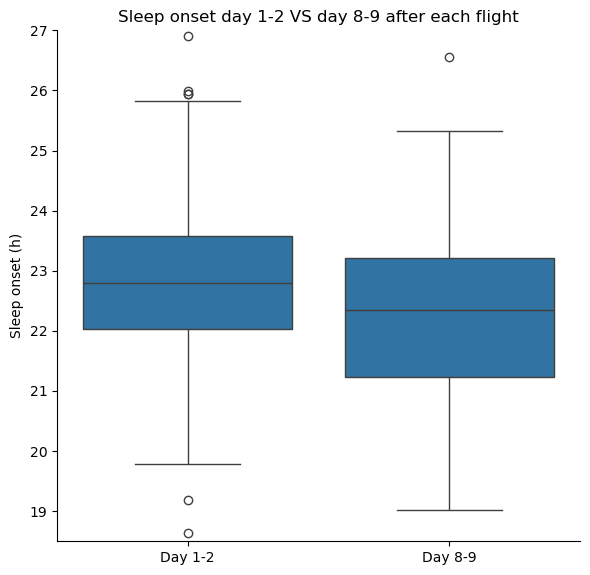

In [110]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='sleep_start_decimal', data=df_flight1)
plt.title('Sleep onset day 1-2 VS day 8-9 after each flight')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep onset (h)')
plt.xlabel('')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(18.5, 27)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [111]:
# Fit the factorial ANOVA model
model4 = ols('sleep_start_decimal ~ C(location) * C(day_after_flight_group)', data=df_flight1).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                           sum_sq     df         F    PR(>F)
C(location)                              0.470537    1.0  0.192084  0.661729
C(day_after_flight_group)               11.546624    1.0  4.713592  0.031272
C(location):C(day_after_flight_group)    8.955046    1.0  3.655651  0.057513
Residual                               428.687781  175.0       NaN       NaN


In [112]:
# Fit a mixed-effects model with random intercepts and slopes for location and flight_id
model5 = smf.mixedlm('sleep_start_decimal ~ C(location) + photoperiod + C(location)*photoperiod + day_after_flight + C(location)*day_after_flight',
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

                    Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     sleep_start_decimal
No. Observations:     644         Method:                 REML               
No. Groups:           47          Scale:                  1.7089             
Min. group size:      1           Log-Likelihood:         -1109.8544         
Max. group size:      46          Converged:              Yes                
Mean group size:      13.7                                                   
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          21.994    0.491 44.799 0.000 21.032 22.956
C(location)[T.UK]                   1.250    0.654  1.913 0.056 -0.031  2.531
photoperiod                         0.030    0.040  0.749 0.454 -0.048  0.108
C(loca

In [113]:
coef_onset = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_onset

,coef,p-value,0.025,0.975
Intercept,21.993841,0.000000,21.031602,22.956079
C(location)[T.UK],1.250250,0.055794,-0.030934,2.531435
photoperiod,0.029968,0.453793,-0.048440,0.108375
C(location)[T.UK]:photoperiod,-0.094327,0.072324,-0.197203,0.008550
day_after_flight,0.014170,0.139878,-0.004643,0.032983
C(location)[T.UK]:day_after_flight,-0.046640,0.037370,-0.090552,-0.002727
Group Var,0.051672,0.073332,-0.004882,0.108225


In [114]:
#drop non significant variables
coef_onset = coef_onset.drop('Intercept')
coef_onset = coef_onset.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\610267020.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)


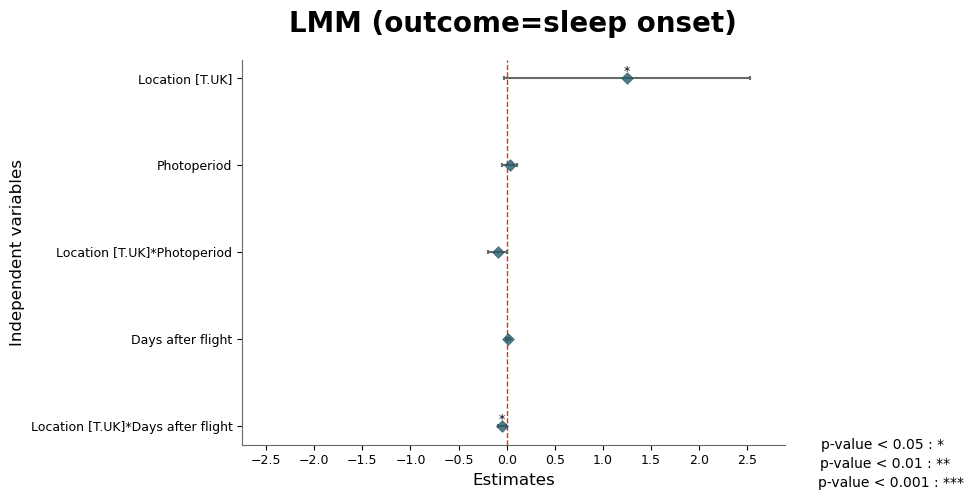

In [115]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_onset.index, data=coef_onset, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_onset.shape[0]):
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.975'].iloc[i], coef_onset['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_onset.shape[0]):
    if coef_onset['p-value'].iloc[i] < 0.001:
        plt.text(coef_onset['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.01:
        plt.text(coef_onset['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.06:
        plt.text(coef_onset['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=sleep onset)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.89)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

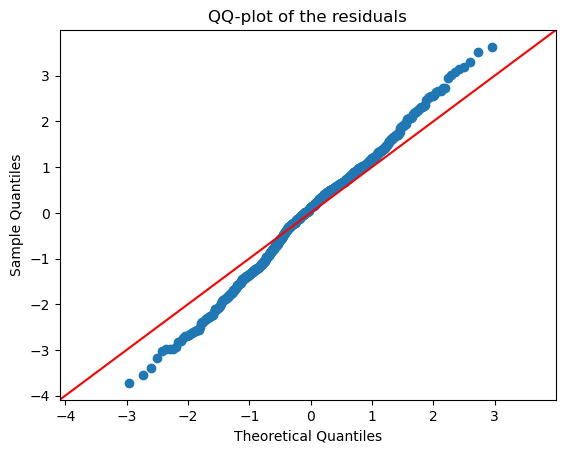

In [116]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [117]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [118]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 3.4896338426842513, p-value: 0.6249567369541909
The residuals are homoscedastic (fail to reject H0).


In [119]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.9224674019416803


In [120]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

In [121]:
#extract from df sunrise and sunset times for both the UK and Italy and create a new dataframe df_daylight
df_daylight1 = pd.read_excel(fpath + '\\1.0_sunset_sunrise_UTC.xlsx', sheet_name='Sheet1')

In [122]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 1:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 0:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

df_daylight1[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df_daylight1.apply(adjust_value, axis=1, result_type='expand')

In [123]:
# Function to convert hours to hh:mm format
def hours_to_hhmm(x, pos):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return f'{hours:02d}:{minutes:02d}'

In [124]:
#add 24 hours to the sleep_start_decimal and sleep_end_decimal
df['sleep_end_decimal_plot'] = df['sleep_end_decimal'] - 24
df['sleep_end_decimal_UTC_plot'] = df['sleep_end_decimal_UTC'] - 24

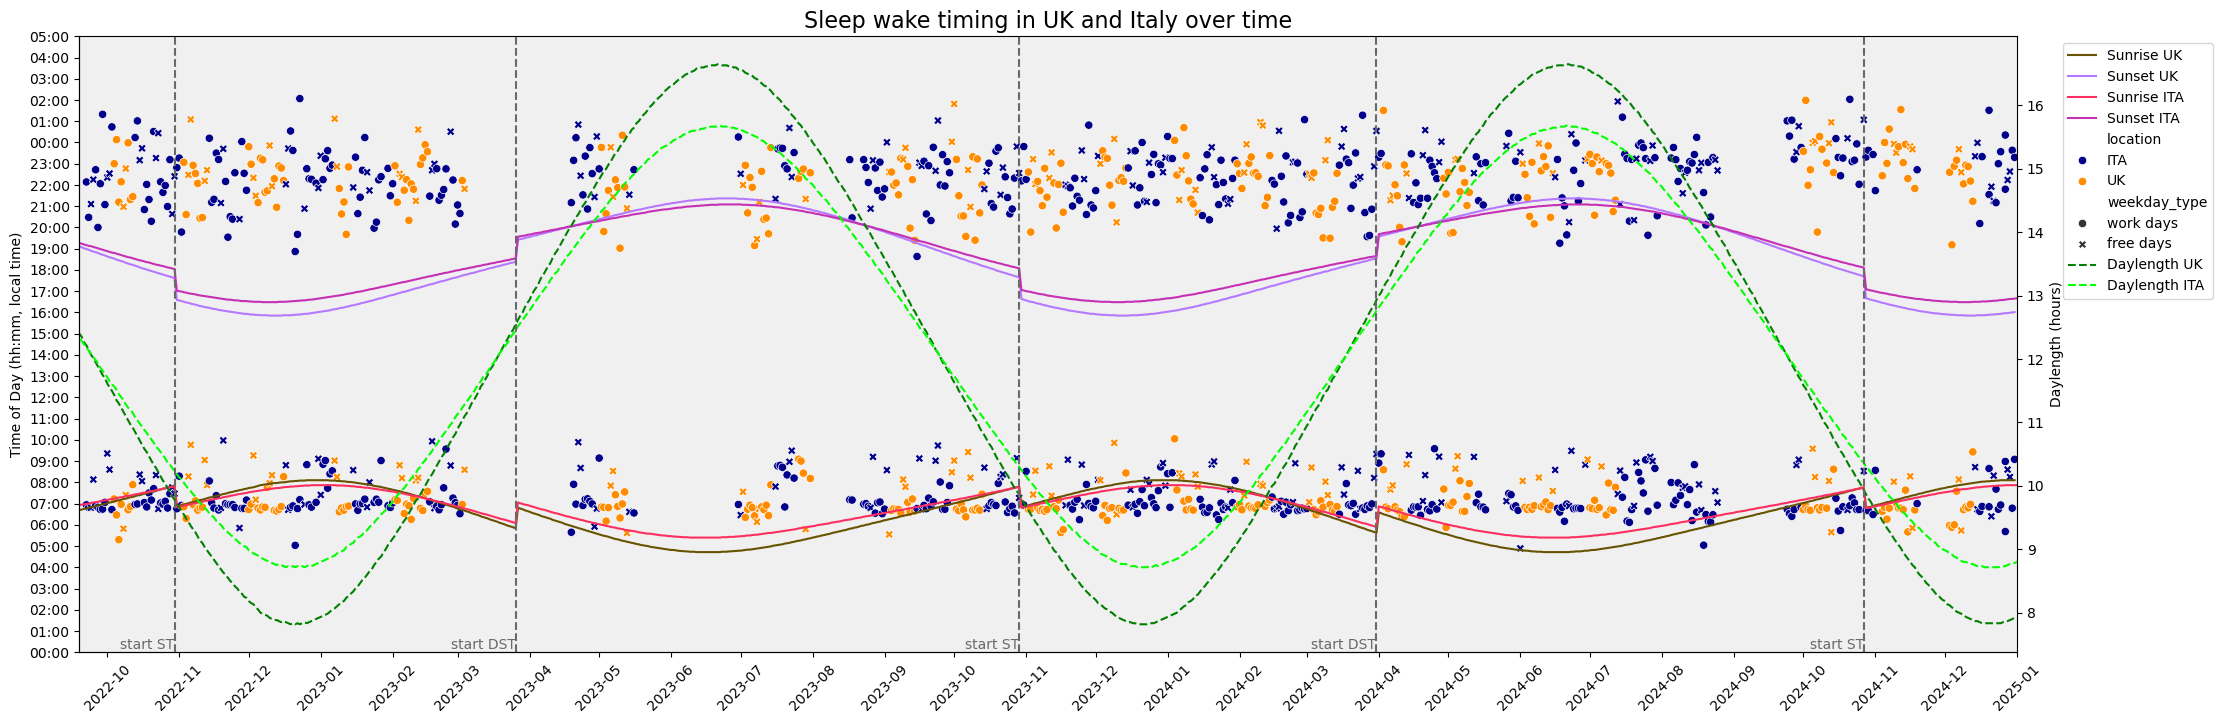

In [125]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight1, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight1, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight1, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight1, label='Sunset ITA', color='#c530b4', ax=ax1)

# sleep onset and offset
sns.scatterplot(x='date', y='sleep_start_decimal', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)
sns.scatterplot(x='date', y='sleep_end_decimal_plot', hue='location', data=df, style='weekday_type', palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df_daylight1['sunset (uk), hours_adjust'] - df_daylight1['sunrise (uk), hours_adjust'], data=df_daylight1, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df_daylight1['sunset (ita), hours_adjust'] - df_daylight1['sunrise (ita), hours_adjust'], data=df_daylight1, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, local time)')
ax1.set_title('Sleep wake timing in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.get_legend().remove()

# Set x-axis major locator of ax1
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

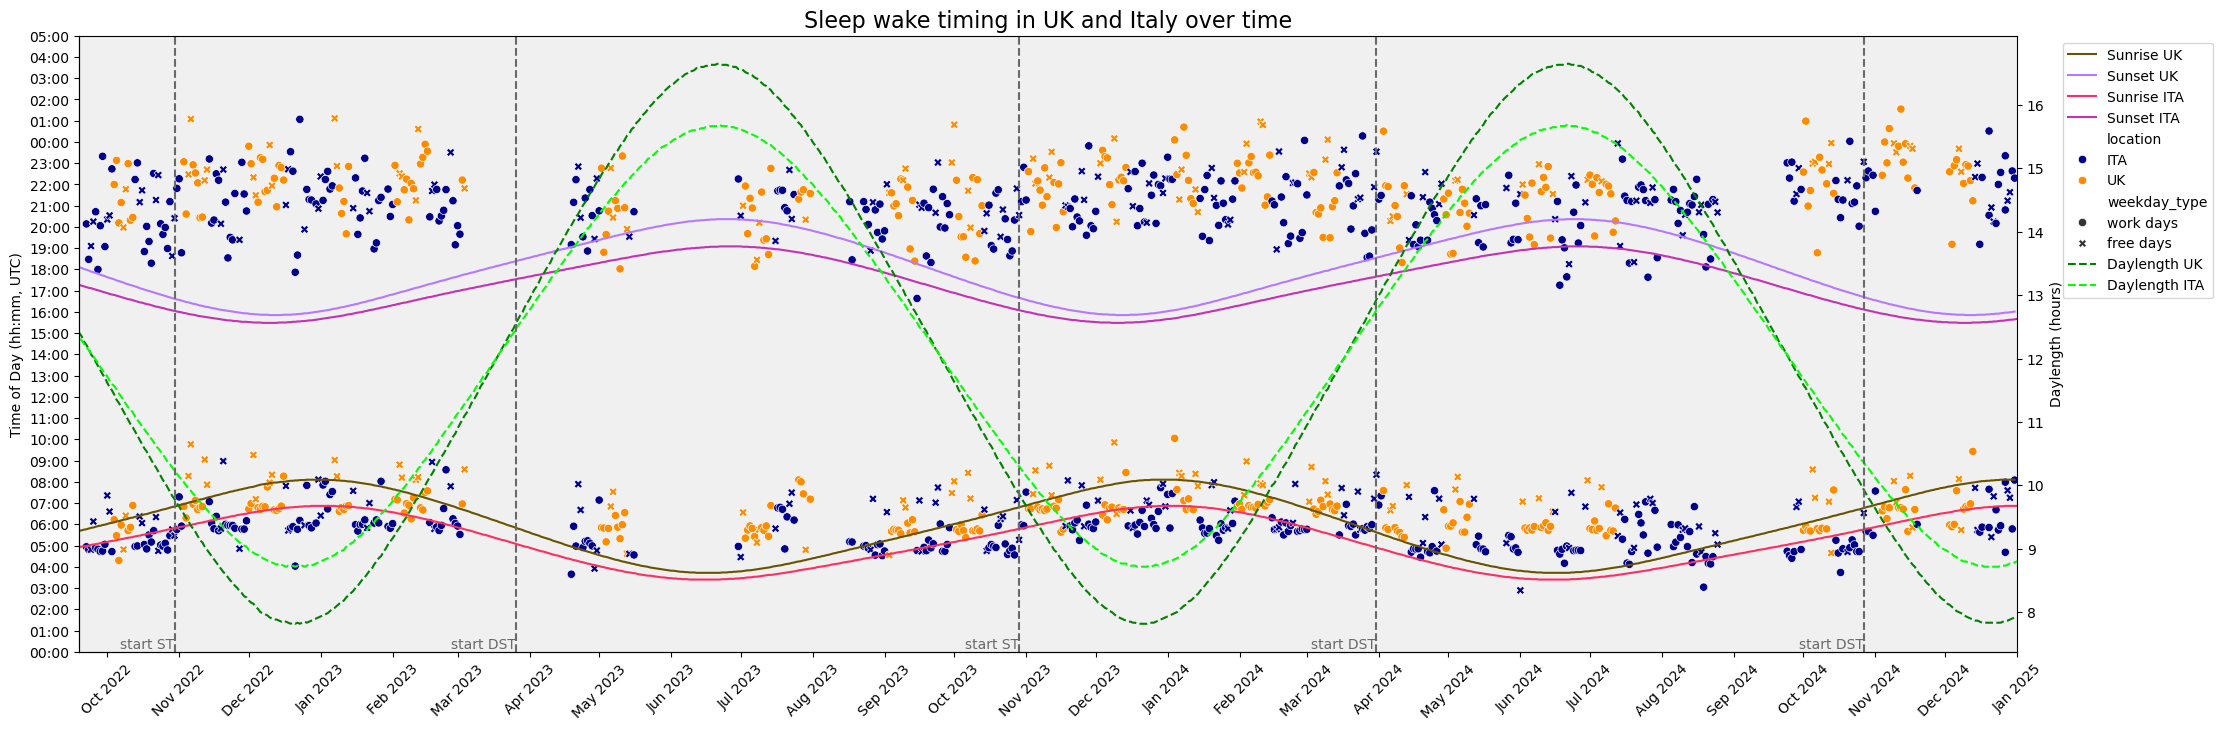

In [126]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours', data=df_daylight1, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours', data=df_daylight1, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours', data=df_daylight1, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours', data=df_daylight1, label='Sunset ITA', color='#c530b4', ax=ax1)

# sleep onset and offset
sns.scatterplot(x='date', y='sleep_start_decimal_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)
sns.scatterplot(x='date', y='sleep_end_decimal_UTC_plot', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df_daylight1['sunset (uk), hours'] - df_daylight1['sunrise (uk), hours'], data=df_daylight1, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df_daylight1['sunset (ita), hours'] - df_daylight1['sunrise (ita), hours'], data=df_daylight1, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, UTC)')
ax1.set_title('Sleep wake timing in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.get_legend().remove()

# Set x-axis major locator of ax1
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start DST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

_Midsleep_

In [127]:
# Order the data by date
df = df.sort_values(by='date')
df_flight1 = df_flight1.sort_values(by='date')

In [128]:
model1 = smf.mixedlm('midsleep_h ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  midsleep_h
No. Observations:   644      Method:              REML      
No. Groups:         47       Scale:               0.8062    
Min. group size:    1        Log-Likelihood:      -858.4794 
Max. group size:    46       Converged:           Yes       
Mean group size:    13.7                                    
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        26.796    0.066 408.646 0.000 26.667 26.924
day_after_flight  0.005    0.006   0.804 0.421 -0.007  0.016
Group Var         0.027    0.021                            



In [129]:
model2 = smf.mixedlm('midsleep_h ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       midsleep_h
No. Observations:        644           Method:                   REML      
No. Groups:              47            Scale:                    0.8028    
Min. group size:         1             Log-Likelihood:           -859.5289 
Max. group size:         46            Converged:                Yes       
Mean group size:         13.7                                              
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       26.837    0.083 323.620 0.000 26.675 27.000
location[T.UK]                   0.045    0.141   0.315 0.753 -0.232  0.321
day_after_flight                 0.008    0.006   1.297 0.195 -0.004  0.021
location[T.UK]:day_after_flight

In [130]:
shapiro_test_midsleep = stats.shapiro(df_flight1['midsleep_h'])

shapiro_test_midsleep

ShapiroResult(statistic=0.971247494051724, pvalue=0.000931566442314773)

In [131]:
ttest_midsleep_days = stats.ttest_ind(df_flight1[df_flight1['day_after_flight_group'] == '0']['midsleep_h'], df_flight1[df_flight1['day_after_flight_group'] == '1']['midsleep_h'])

ttest_midsleep_days

TtestResult(statistic=1.9850513927887998, pvalue=0.04868345858193058, df=177.0)

In [132]:
# mean and std of midsleep by day_after_flight_group 
df_grouped_flight = df_flight1.groupby(['day_after_flight_group']).agg({'midsleep_h': ['mean', 'std']})
df_grouped_flight

midsleep_h          
                             mean       std
day_after_flight_group                     
0                       27.162545  1.055596
1                       26.835078  1.151529

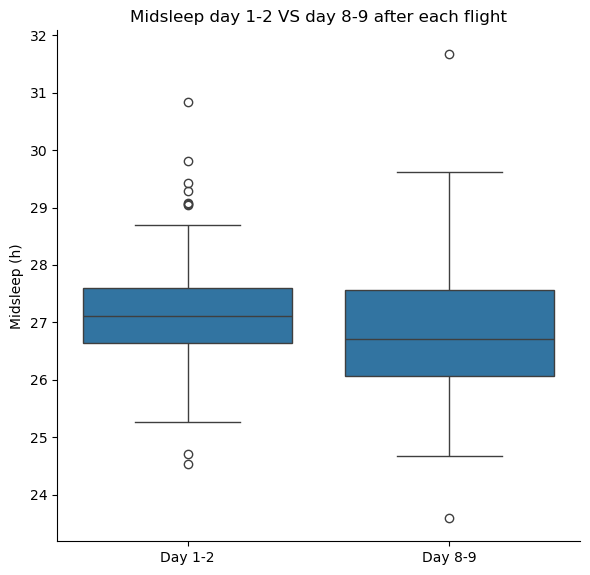

In [133]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='midsleep_h', data=df_flight1)
plt.title('Midsleep day 1-2 VS day 8-9 after each flight')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Midsleep (h)')
plt.xlabel('')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
#plt.ylim(18.5, 27)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [134]:
# Fit the factorial ANOVA model
model4 = ols('midsleep_h ~ C(location) * C(day_after_flight_group)', data=df_flight1).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                           sum_sq     df         F    PR(>F)
C(location)                              2.114311    1.0  1.770270  0.185080
C(day_after_flight_group)                4.836650    1.0  4.049630  0.045714
C(location):C(day_after_flight_group)    4.101175    1.0  3.433831  0.065558
Residual                               209.010176  175.0       NaN       NaN


In [135]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5 = smf.mixedlm('midsleep_h ~ C(location) + day_after_flight + photoperiod + photoperiod*C(location) + C(location)*day_after_flight', 
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        midsleep_h
No. Observations:        644            Method:                    REML      
No. Groups:              47             Scale:                     0.8039    
Min. group size:         1              Log-Likelihood:            -863.3287 
Max. group size:         46             Converged:                 Yes       
Mean group size:         13.7                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          26.568    0.284 93.522 0.000 26.011 27.124
C(location)[T.UK]                   0.735    0.388  1.895 0.058 -0.025  1.495
day_after_flight                    0.009    0.006  1.428 0.153 -0.003  0.021
C(loca

In [136]:
# calculate log-likelihood of model2a
#ll_model5 = model5.llf
#ll_model5 = model5.llf

# calculate likelihood ratio Chi-Squared test statistic
#lr_test1 = 2 * (ll_model5 - model5.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
#p_value = stats.chi2.sf(lr_test1, 2)

#print('Likelihood ratio test results:')
#print('Chi-Squared test statistic:', lr_test1)
#print('P-value:', p_value)

In [137]:
coef_midsleep = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_midsleep

,coef,p-value,0.025,0.975
Intercept,26.567688,0.000000,26.010900,27.124476
C(location)[T.UK],0.734827,0.058035,-0.025018,1.494673
day_after_flight,0.008873,0.153400,-0.003309,0.021055
C(location)[T.UK]:day_after_flight,-0.030768,0.041094,-0.060292,-0.001245
photoperiod,0.022855,0.326990,-0.022845,0.068554
photoperiod:C(location)[T.UK],-0.058964,0.056573,-0.119578,0.001650
Group Var,0.019909,0.367759,-0.023415,0.063233


In [138]:
#drop non significant variables
coef_midsleep = coef_midsleep.drop('Intercept')
coef_midsleep = coef_midsleep.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\1132575144.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location [T.UK]', 'Days after flight', 'Location[T.UK]*Days after flight', 'Photoperiod', 'Photoperiod*Location [T.UK]',], fontsize=9)


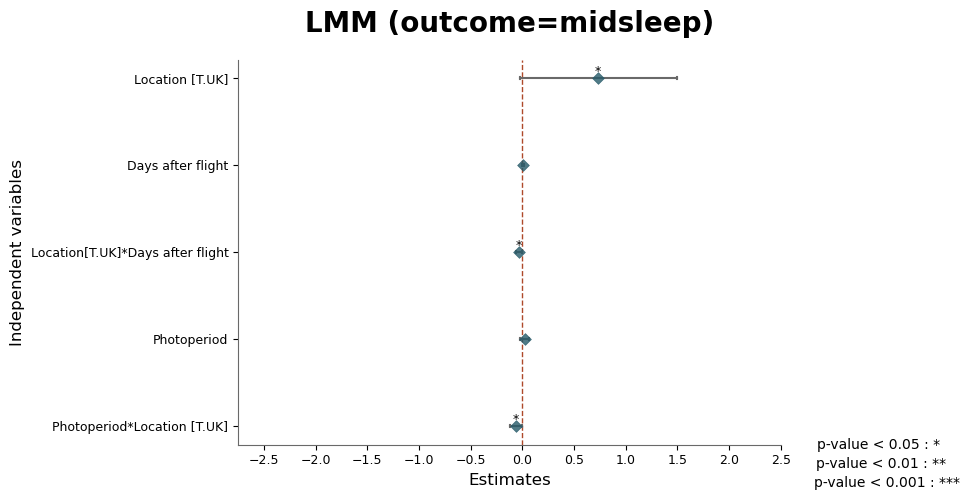

In [139]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_midsleep.index, data=coef_midsleep, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_midsleep.shape[0]):
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.975'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_midsleep.shape[0]):
    if coef_midsleep['p-value'].iloc[i] < 0.001:
        plt.text(coef_midsleep['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.01:
        plt.text(coef_midsleep['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.06:
        plt.text(coef_midsleep['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=midsleep)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Days after flight', 'Location[T.UK]*Days after flight', 'Photoperiod', 'Photoperiod*Location [T.UK]',], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

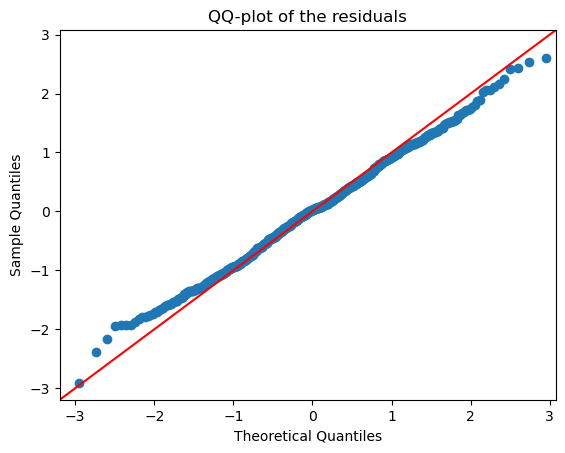

In [140]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [141]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [142]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 6.202968433594645, p-value: 0.28696725794708294
The residuals are homoscedastic (fail to reject H0).


In [143]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.6901394678030954


In [144]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

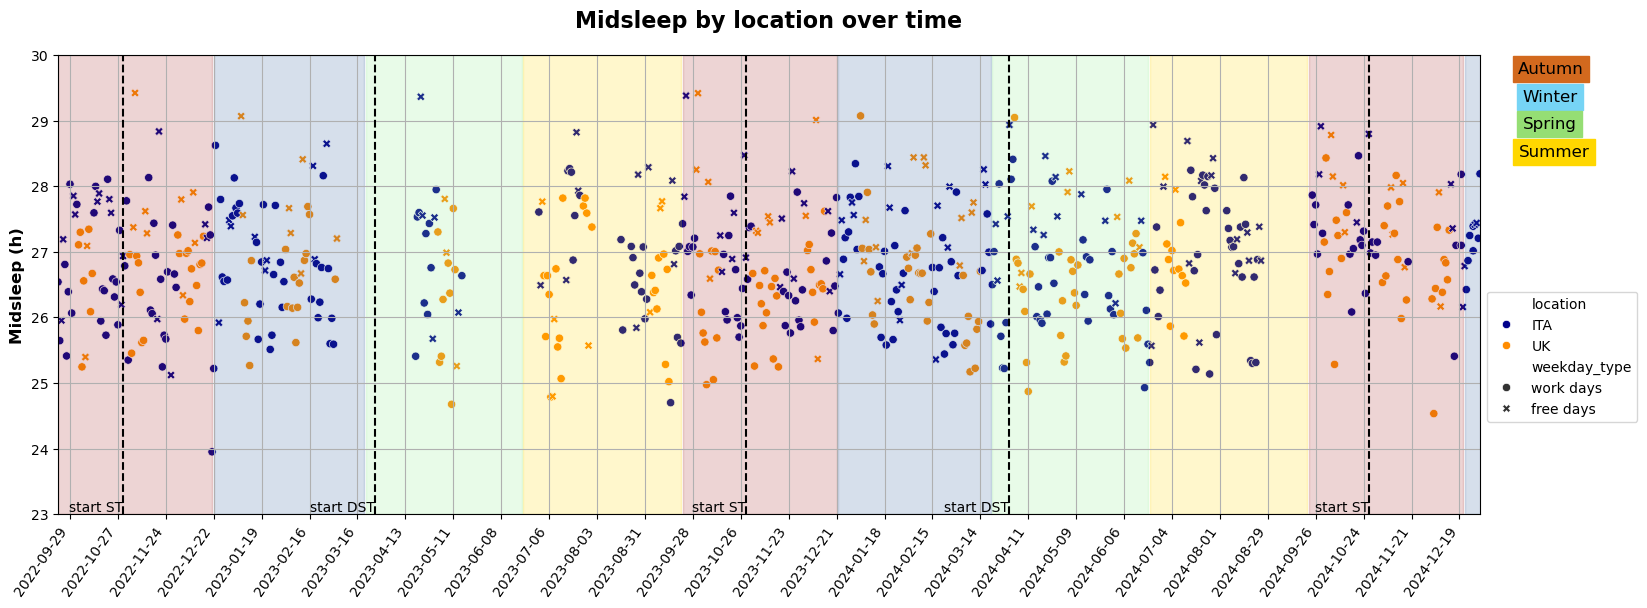

In [145]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend(loc='upper left', bbox_to_anchor=(1, 0.5)) 
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca
plt.ylim(23,30)

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
    ('2024-12-22', '2025-03-20', '#335f9e'),  # Winter
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.052, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.05, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.049, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.049, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

#plt.xlim(pd.to_datetime('2024-03-28'), pd.to_datetime('2024-04-27'))

plt.show()

_Phase (wake up time - sunrise)_

In [146]:
df2 = df
df2_x = df_flight1

In [147]:
# test the skewness of the phase data
skewness = skew(df2['phase'])

print(f"Index of skewness: {skewness}")

Index of skewness: 0.5800883335298199


In [148]:
# test the kurtosis of the phase data
kurtosis_value = kurtosis(df2['phase'])

print(f"Index of kurtosis: {kurtosis_value}")

Index of kurtosis: -0.24439117410499023


In [149]:
#phase_data = df2['phase'].values.reshape(-1, 1)

# apply the Yeo-Johnson transformation
#pt = PowerTransformer(method='yeo-johnson')
#phase_transformed = pt.fit_transform(phase_data)

In [150]:
# add the transformed phase to the dataframe 
#df2['phase_transformed'] = phase_transformed

In [151]:
# test the best distribution for the phase data
distributions = ['norm', 'gamma', 'lognorm', 'expon']
best_fit_results = {}

In [152]:
# Filter out invalid values (e.g., negative values or zeros) for distributions that require positive values
valid_phase = df2["phase"][df2["phase"] > 0]

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    if dist_name in ['gamma', 'lognorm', 'expon']:
        params = dist.fit(valid_phase)
        ks_stat, ks_pval = stats.kstest(valid_phase, dist_name, args=params)
    else:
        params = dist.fit(df2["phase"])
        ks_stat, ks_pval = stats.kstest(df2["phase"], dist_name, args=params)
    best_fit_results[dist_name] = ks_stat  # save the KS statistic

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\scipy\stats\_continuous_distns.py:6545: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


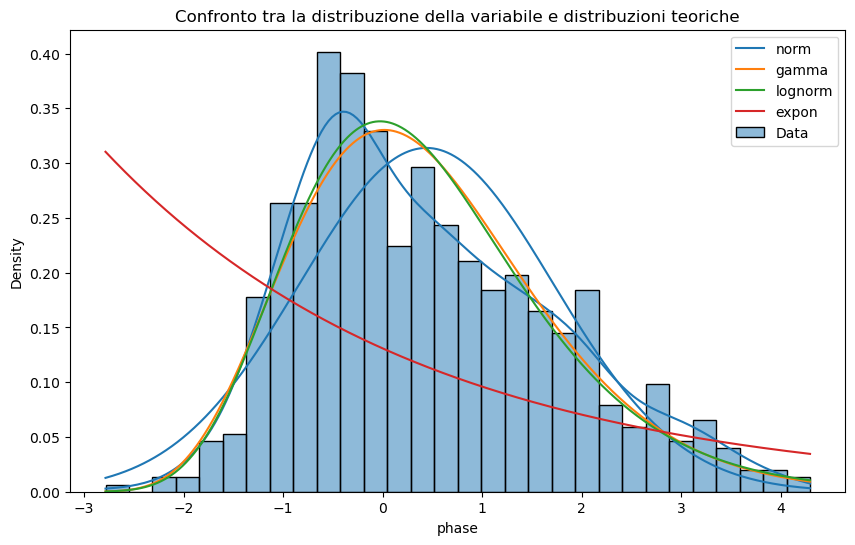

In [153]:
# plot of the best fit results
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df2["phase"], bins=30, kde=True, stat="density", label="Data", ax=ax)

x = np.linspace(df2["phase"].min(), df2["phase"].max(), 1000)

# Disegniamo le distribuzioni teoriche
for dist_name in best_fit_results.keys():
    dist = getattr(stats, dist_name)
    params = dist.fit(df2["phase"])
    pdf = dist.pdf(x, *params)
    ax.plot(x, pdf, label=f"{dist_name}")

ax.legend()
ax.set_title("Confronto tra la distribuzione della variabile e distribuzioni teoriche")
plt.show()

In [154]:
# Shapiro-Wilk test for the transformed phase
shapiro_test_phase = stats.shapiro(df2['phase'])
shapiro_test_phase

ShapiroResult(statistic=0.9660753934039342, pvalue=4.762334396228607e-11)

In [155]:
model1 = smf.mixedlm('phase ~ day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  phase    
No. Observations:   644      Method:              REML     
No. Groups:         47       Scale:               0.8132   
Min. group size:    1        Log-Likelihood:      -914.8450
Max. group size:    46       Converged:           Yes      
Mean group size:    13.7                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.583    0.154  3.794 0.000  0.282  0.884
day_after_flight -0.013    0.006 -2.033 0.042 -0.026 -0.000
Group Var         0.917    0.239                           



In [156]:
model2 = smf.mixedlm('phase ~ day_after_flight + C(location) + C(location)*day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        phase    
No. Observations:         644            Method:                    REML     
No. Groups:               47             Scale:                     0.8145   
Min. group size:          1              Log-Likelihood:            -918.3559
Max. group size:          46             Converged:                 Yes      
Mean group size:          13.7                                               
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.569    0.215  2.647 0.008  0.148  0.990
C(location)[T.UK]                   0.027    0.316  0.085 0.932 -0.593  0.646
day_after_flight                   -0.013    0.007 -1.828 0.067 -0.027  0.001
C(loca

In [157]:
shapiro_test_midsleep = stats.shapiro(df2_x['phase'])

shapiro_test_midsleep

ShapiroResult(statistic=0.9668004861731739, pvalue=0.0002905912484067863)

In [158]:
utest_phase_days = stats.mannwhitneyu(df2_x[df2_x['day_after_flight_group'] == '0']['phase'], df2_x[df2_x['day_after_flight_group'] == '1']['phase'])

utest_phase_days

MannwhitneyuResult(statistic=4255.0, pvalue=0.4607223288141967)

In [159]:
# Fit the factorial ANOVA model
model4 = ols('phase ~ C(location) * C(day_after_flight_group)', data=df2_x).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                           sum_sq     df         F    PR(>F)
C(location)                              1.189796    1.0  0.541162  0.462936
C(day_after_flight_group)                1.680281    1.0  0.764253  0.383199
C(location):C(day_after_flight_group)    0.882498    1.0  0.401392  0.527198
Residual                               384.754027  175.0       NaN       NaN


In [160]:
# Fit a mixed-effects model with random intercepts for each day after flight
# re_formula="~1": This specifies that the random effects are independent and only include a random intercept for each group 
# i.e. each group has its own intercept, but the slopes are assumed to be the same across groups
model5a = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_1) + C(location)*photoperiod', data=df2, groups=df2['flight_id'], re_formula='~1').fit(method='powell', maxiter=1000)

print(model5a.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       phase    
No. Observations:       644           Method:                   REML     
No. Groups:             47            Scale:                    0.7877   
Min. group size:        1             Log-Likelihood:           -848.8086
Max. group size:        46            Converged:                Yes      
Mean group size:        13.7                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                     -4.408    0.310 -14.242 0.000 -5.015 -3.802
C(location)[T.UK]              0.176    0.344   0.511 0.609 -0.498  0.850
C(DST_1)[T.1]                 -0.709    0.123  -5.760 0.000 -0.950 -0.468
photoperiod                    0.451    0.030  15.057 0.

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [161]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5b = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_1) + day_after_flight + photoperiod*C(location) + C(location)*day_after_flight', data=df2, groups=df2['flight_id']).fit(method='powell', maxiter=1000)

print(model5b.summary())

                    Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        phase    
No. Observations:          644            Method:                    REML     
No. Groups:                47             Scale:                     0.7881   
Min. group size:           1              Log-Likelihood:            -856.0423
Max. group size:           46             Converged:                 Yes      
Mean group size:           13.7                                               
------------------------------------------------------------------------------
                                   Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                          -4.435    0.325 -13.643 0.000 -5.072 -3.798
C(location)[T.UK]                   0.284    0.372   0.762 0.446 -0.446  1.014
C(DST_1)[T.1]                      -0.715    0.125  -5.728 0.000 -0.960 -

In [162]:
# calculate log-likelihood of model2a
ll_model5a = model5a.llf
ll_model5b = model5b.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model5a - model5b.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 14.467406532428868
P-value: 0.0007218427314936338


In [163]:
coef_phase = pd.DataFrame({'coef': model5a.params.values, 'p-value': model5a.pvalues.values, '0.025': model5a.conf_int()[0], '0.975': model5a.conf_int()[1]})
coef_phase

,coef,p-value,0.025,0.975
Intercept,-4.408146,5.023947e-46,-5.014787,-3.801504
C(location)[T.UK],0.175914,6.090366e-01,-0.498220,0.850048
C(DST_1)[T.1],-0.709091,8.412386e-09,-0.950375,-0.467807
photoperiod,0.450560,3.096404e-51,0.391911,0.509208
C(location)[T.UK]:photoperiod,-0.011007,7.060604e-01,-0.068205,0.046192
Group Var,0.010840,6.237568e-01,-0.032471,0.054150


In [164]:
#drop non significant variables
coef_phase = coef_phase.drop('Intercept')
coef_phase = coef_phase.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_19008\3266223409.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.DST]', 'Photoperiod', 'Location[T.UK]*Photoperiod'])


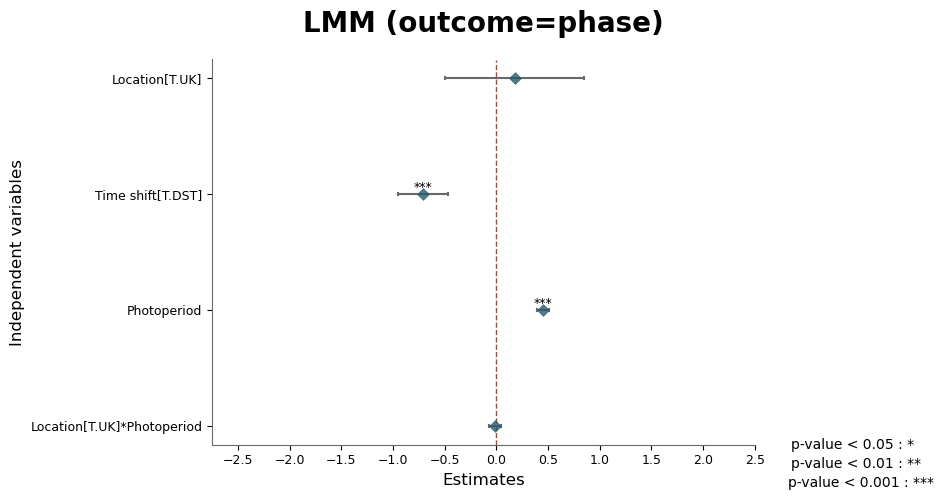

In [165]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_phase.index, data=coef_phase, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_phase.shape[0]):
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.975'].iloc[i], coef_phase['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_phase.shape[0]):
    if coef_phase['p-value'].iloc[i] < 0.001:
        plt.text(coef_phase['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.01:
        plt.text(coef_phase['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.05:
        plt.text(coef_phase['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=phase)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.DST]', 'Photoperiod', 'Location[T.UK]*Photoperiod'])

plt.show()

<Figure size 800x600 with 0 Axes>

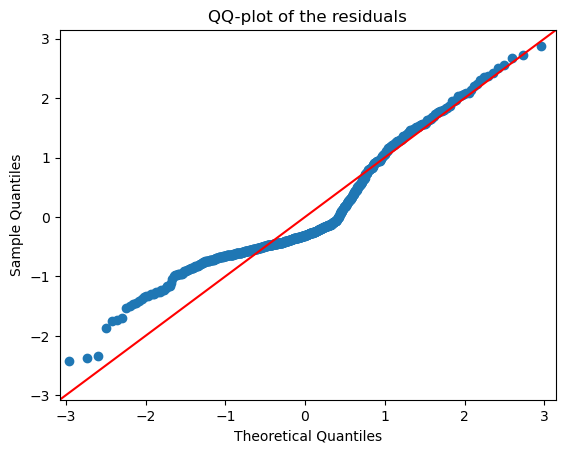

In [166]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5b.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [167]:
residualsX = model5b.resid 
predictedX = model5b.fittedvalues

In [168]:
# Breusch-Pagan test for homoscedasticity
bp_testX = het_breuschpagan(residualsX, model5b.model.exog)

# results of the Breusch-Pagan test
bp_statX, bp_pvalX, _, _ = bp_testX
print(f'Breusch-Pagan statistic: {bp_statX}, p-value: {bp_pvalX}')
if bp_pvalX > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 10.420149507716689, p-value: 0.10803756088759511
The residuals are homoscedastic (fail to reject H0).


In [169]:
# Durbin-Watson test for autocorrelation
durbin_watson_testX = durbin_watson(residualsX)

print('Durbin-Watson test:', durbin_watson_testX)

Durbin-Watson test: 1.6993671904763608


In [170]:
# Order the dat to fit the GEE model
df2 = df2.sort_values(by='date')

# define the structure of the GEE model(Autoregressive) to capture the temporal dependence
cov_str = sm.cov_struct.Autoregressive() # For longitudinal data: proximate data points exhibit stronger correlation than distant data points

# GEE model with random intercepts for each date
gee_model = smf.gee(
    'phase ~ C(location) + C(DST_1) + day_after_flight + photoperiod + C(location)*photoperiod + C(location)*day_after_flight',
    data=df2,
    groups=df2['flight_id'],  # to model the intra-day post-flight correlation: 
                                     # if the day after flight affects sleep in a systematic way and if observations from the same day_after_flight are more similar to each other than observations from different days
    cov_struct=cov_str,
    family=sm.families.Gaussian()
).fit()

gee_model.summary()

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\genmod\cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                       phase   No. Observations:                  644
Model:                                 GEE   No. clusters:                       47
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                  46
Family:                           Gaussian   Mean cluster size:                13.7
Dependence structure:       Autoregressive   Num. iterations:                    48
Date:                     Mon, 03 Mar 2025   Scale:                           0.797
Covariance type:                    robust   Time:                         17:26:33
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -4.3631      0.266    -16.384      0.000      -4.885      -3.841
C(location)[T.UK]                      0.2322      0.337      0.688      0.491      -0.429       0.894
C(DST_1)[T.1]                         -0.6999      0.097     -7.217      0.000      -0.890      -0.510
day_after_flight                       0.0009      0.009      0.106      0.915      -0.016       0.018
C(location)[T.UK]:day_after_flight    -0.0115      0.015     -0.786      0.432      -0.040       0.017
photoperiod                            0.4459      0.027     16.235      0.000       0.392       0.500
C(location)[T.UK]:photoperiod         -0.0083      0.029     -0.288      0.773      -0.065       0.048
==============================================================================
Skew:                          0.8450   Kurtosis:                       0.3247
Centered skew:                 0.7913   Centered kurtosis:              0.4847
==============================================================================
"""

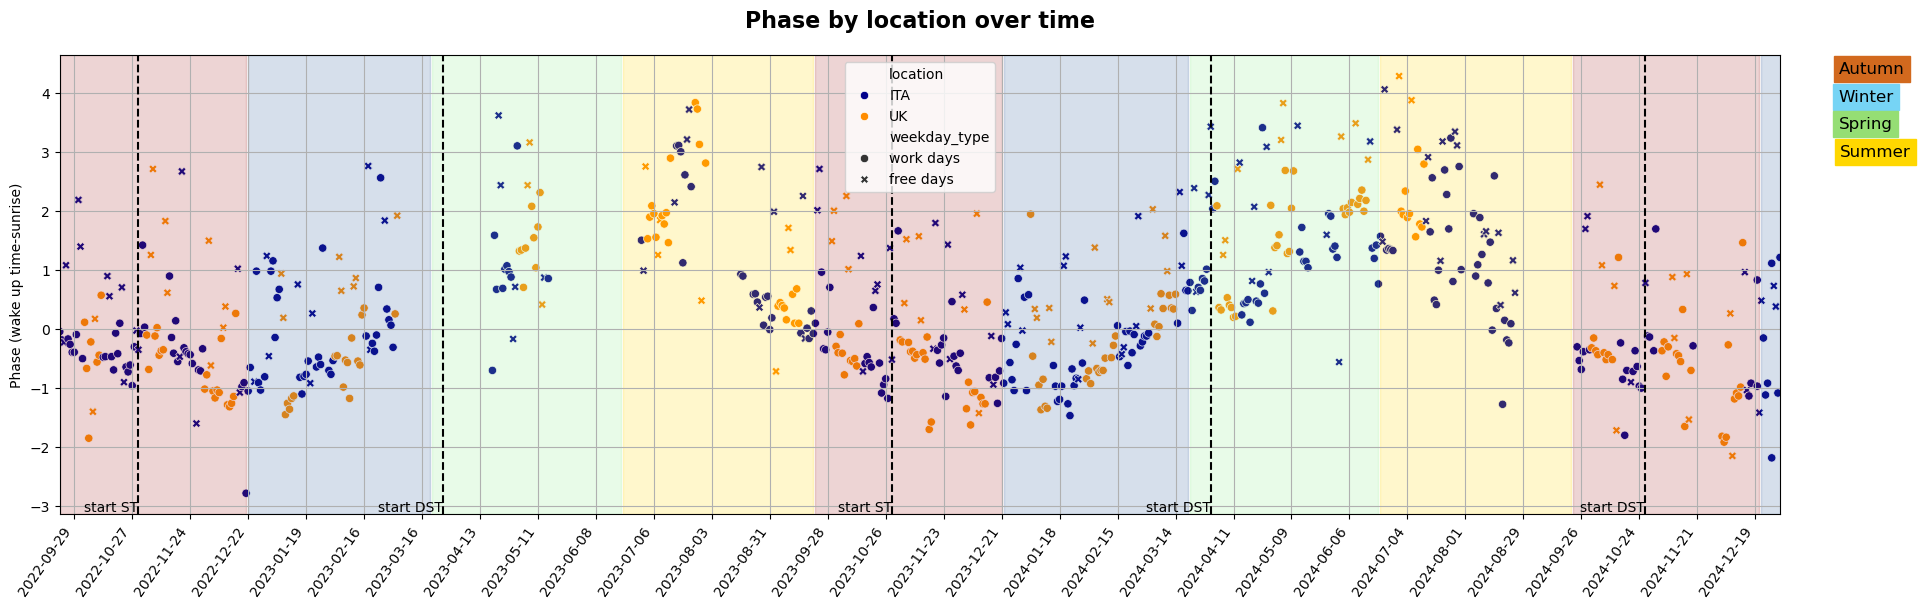

In [171]:
plt.figure(figsize=(18, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (wake up time-sunrise)')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
    ('2024-12-22', '2025-03-20', '#335f9e'),  # Winter
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

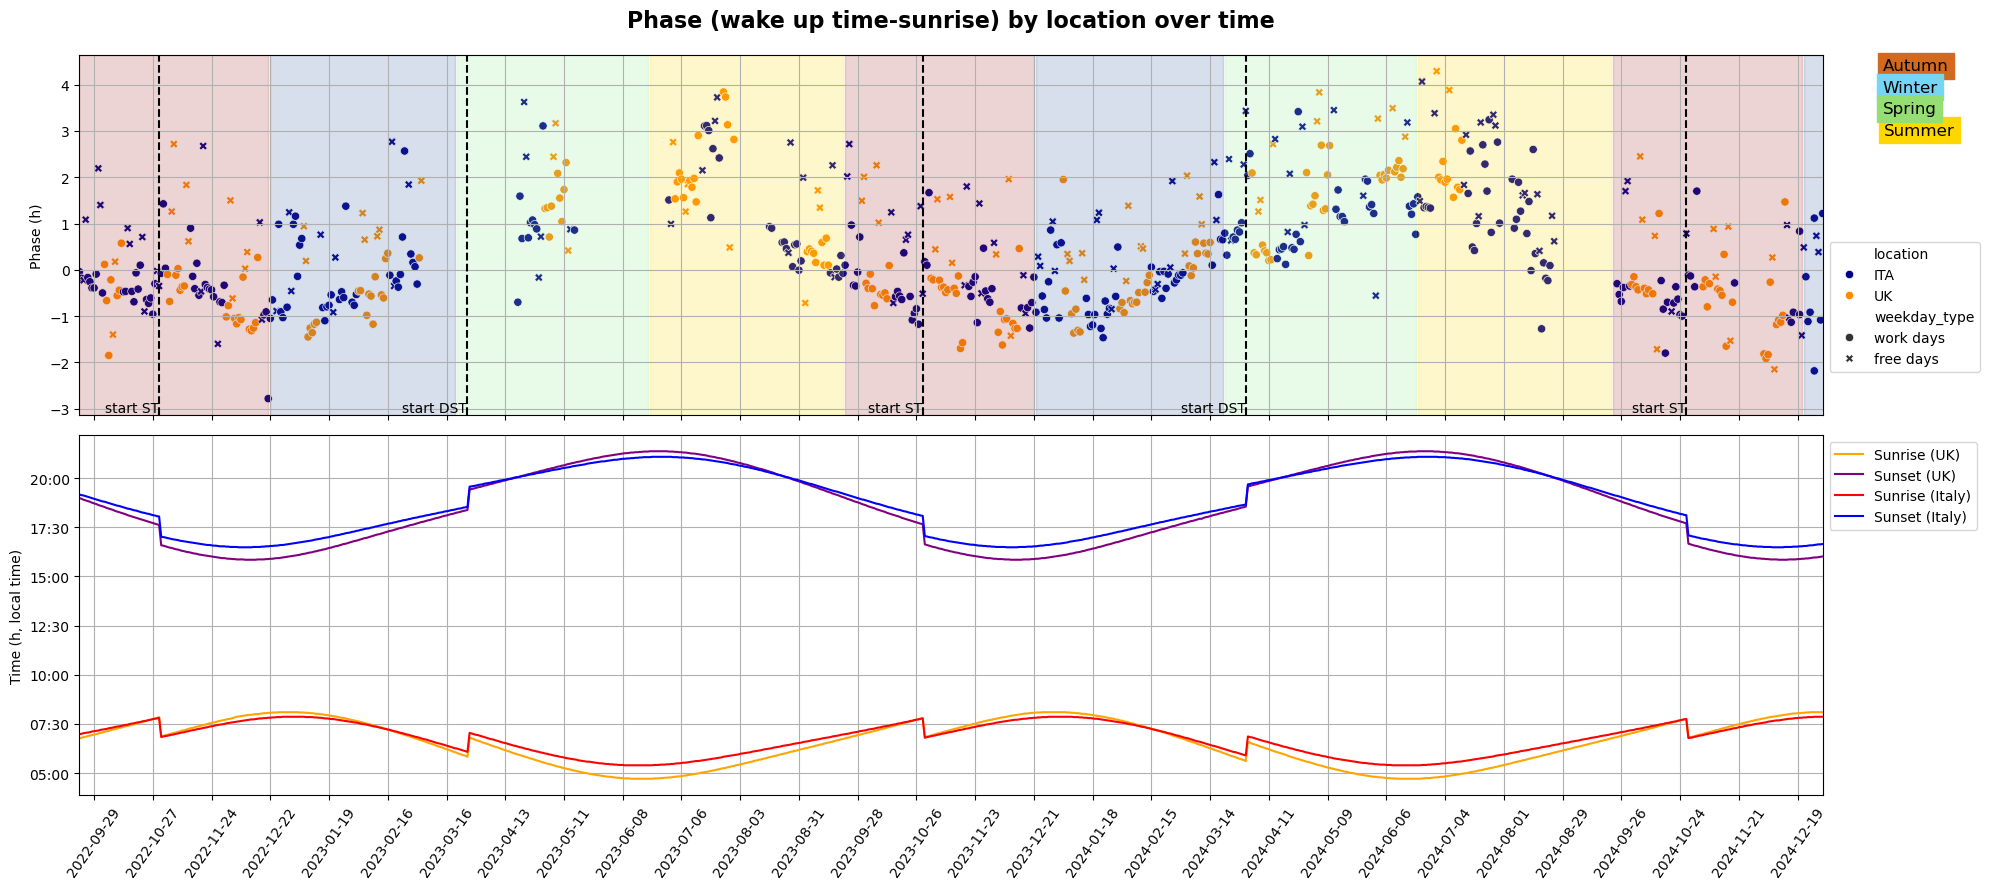

In [172]:
# Create a figure with two subplots (one above the other) with adjusted height ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 9), sharex=True, gridspec_kw={'height_ratios': [5, 5]})

# Plot the phase by location over time in the top subplot
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'], ax=ax1)
ax1.set_title('Phase (wake up time-sunrise) by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
ax1.set_ylabel('Phase (h)')
ax1.set_xlabel('')
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='x', rotation=55)
ax1.set_xlim(df2['date'].min(), df2['date'].max())
ax1.xaxis.set_major_locator(MultipleLocator(28))  # Set the x-axis major locator

#  set the legend outside the plot
ax1.legend(loc='upper left', bbox_to_anchor=(1, 0.5))

# Add vertical bars to indicate the start of DST and ST
dst_st_dates = [
    ('2022-10-30', 'start ST'),
    ('2023-10-29', 'start ST'),
    ('2023-03-26', 'start DST'),
    ('2024-03-31', 'start DST'),
    ('2024-10-27', 'start ST')
]
for date, label in dst_st_dates:
    ax1.axvline(x=pd.to_datetime(date), color='black', linestyle='--')
    ax1.text(pd.to_datetime(date), ax1.get_ylim()[0], label, ha='right', va='bottom')

# Define seasons and apply background color for each season
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
    ('2024-12-22', '2025-03-20', '#335f9e'),  # Winter
]
for start, end, color in seasons:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

# Annotate the seasons
season_annotations = [
    ('Summer', 1.0555, 0.79, 'gold'),
    ('Autumn', 1.0535, 0.97, 'chocolate'),
    ('Winter', 1.05, 0.91, '#76d4f5'),
    ('Spring', 1.0499, 0.85, '#95de74')
]
for label, x, y, color in season_annotations:
    ax1.annotate(label, xy=(x, y), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor=color)

# Plot the sunrise and sunset times in the bottom subplot
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight1, ax=ax2, label='Sunrise (UK)', color='orange')
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight1, ax=ax2, label='Sunset (UK)', color='purple')
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight1, ax=ax2, label='Sunrise (Italy)', color='red')
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight1, ax=ax2, label='Sunset (Italy)', color='blue')

ax2.set_ylabel('Time (h, local time)')
ax2.set_xlabel('')
# Format y-axis to hh:mm
ax2.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
ax2.grid(True)
ax2.tick_params(axis='x', rotation=55)
ax2.set_xlim(df2['date'].min(), df2['date'].max())
ax2.xaxis.set_major_locator(MultipleLocator(28))  # Set the x-axis major locator

#  set the legend outside the plot
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


Wake After Sleep Onset

In [173]:
# drop the nan values in the waso_min column
df_waso_clean = df.dropna(subset=['waso'])
df_waso_clean_x = df_flight1.dropna(subset=['waso'])

In [174]:
model1a = smf.mixedlm('waso ~ day_after_flight', df_waso_clean, groups=df_waso_clean['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1a.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  waso      
No. Observations:  640      Method:              REML      
No. Groups:        47       Scale:               860.9606  
Min. group size:   1        Log-Likelihood:      -3087.2820
Max. group size:   45       Converged:           Yes       
Mean group size:   13.6                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        50.460    2.391 21.101 0.000 45.773 55.147
day_after_flight  0.126    0.197  0.639 0.523 -0.260  0.511
Group Var        78.868    1.107                           



In [175]:
model2 = smf.mixedlm('waso ~ day_after_flight + C(location) + C(location)*day_after_flight', df_waso_clean, groups=df_waso_clean['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        waso      
No. Observations:        640            Method:                    REML      
No. Groups:              47             Scale:                     854.0812  
Min. group size:         1              Log-Likelihood:            -3075.5758
Max. group size:         45             Converged:                 Yes       
Mean group size:         13.6                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          42.000    2.902 14.472 0.000 36.312 47.688
C(location)[T.UK]                  21.124    4.851  4.355 0.000 11.616 30.632
day_after_flight                    0.442    0.212  2.085 0.037  0.027  0.858
C(loca

In [176]:
shapiro_test_midsleep = stats.shapiro(df_waso_clean_x['waso'])

shapiro_test_midsleep

ShapiroResult(statistic=0.9825625772533118, pvalue=0.02526918480114148)

In [177]:
utest_waso_days = stats.mannwhitneyu(df_waso_clean_x[df_waso_clean_x['day_after_flight_group'] == '0']['waso'], df_waso_clean_x[df_waso_clean_x['day_after_flight_group'] == '1']['waso'])

utest_waso_days

MannwhitneyuResult(statistic=3286.0, pvalue=0.05127974465522627)

In [178]:
# mean and std of midsleep by day_after_flight_group
df_grouped_flight = df_waso_clean_x.groupby(['day_after_flight_group']).agg({'waso': ['mean', 'std']})
df_grouped_flight

waso           
                             mean        std
day_after_flight_group                      
0                       49.576087  27.700610
1                       58.395349  31.140395

In [179]:
# Fit the factorial ANOVA model
model4 = ols('waso ~ C(location) * C(day_after_flight_group)', data=df_waso_clean_x).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model4, typ=2)

print(anova_results)

                                              sum_sq     df          F  \
C(location)                              9856.926805    1.0  12.238668   
C(day_after_flight_group)                3602.833023    1.0   4.473390   
C(location):C(day_after_flight_group)    2257.865318    1.0   2.803436   
Residual                               140138.233408  174.0        NaN   

                                         PR(>F)  
C(location)                            0.000594  
C(day_after_flight_group)              0.035850  
C(location):C(day_after_flight_group)  0.095859  
Residual                                    NaN  
